In [1]:
import os
import sys
import math
import copy
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import numpy as np
import gymnasium as gym
from gymnasium.spaces.utils import flatten, flatdim

from rl_firm.env import BaselineABMEnv
from rl_firm.ppo_lstm_truncated import PPOAgent

In [2]:
N_BAD_MONTHS = 24
MODEL_PATH = os.path.join(os.path.abspath(os.path.join('..')), 'results/model/lstm_truncated/2m_anneal.pt')
MODEL_PATH

'/Users/hieule/Projects/rl-firm-lengnick-abm/results/model/lstm_truncated/2m_anneal.pt'

## Helper functions

In [3]:
# -----------------------------
# Basic helpers
# -----------------------------

def load_burned_in_model(model_seed):
    with open(f'../snapshots/macro/abm_{model_seed}.pkl', 'rb') as f:
        print(f'Loading macro model seed {model_seed}')
        return pickle.load(f)


def seed_everything(run_seed, model=None):
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)

    if model is not None:
        model.random.seed(run_seed)


def load_lstm_agent(obs_dim, model_path=MODEL_PATH, device=None):
    if device is None:
        device = torch.device("mps" if hasattr(torch, "mps") and torch.mps.is_available() else "cpu")

    agent = PPOAgent(obs_dim=obs_dim).to(device)
    agent.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    agent.eval()
    return agent, device

In [6]:
model = load_burned_in_model(20)
len(model.firms),  len(model.learning_firms)

Loading macro model seed 20


(100, 100)

In [4]:
# -----------------------------
# Observation helpers
# -----------------------------

def get_obs_for_firm(firm):
    """
    Same observation contents as BaselineABMEnv._get_obs(),
    but for an arbitrary firm.
    """
    return {
        "open_position": int(firm.open_position),
        "months_since_hire_failure": firm.months_since_hire_failure,
        "employee_count": firm.employee_count,
        "liquidity_buffer": firm.liquidity_buffer,
        "inventories": firm.inventories,
        "wage_rate": firm.wage_rate,
        "goods_price": firm.goods_price,
        "last_month_demand": firm.last_month_demand,
    }


def flat_obs_for_firm(firm, obs_space):
    return flatten(obs_space, get_obs_for_firm(firm)).astype(np.float32)

In [5]:
# -----------------------------
# Adoption assignment
# -----------------------------

def select_learning_firms(
    model,
    adoption_rate,
    run_seed,
    prefer_existing_single=True,
    select_from_active=False,
):
    """
    Selects firms assigned to the learned policy.

    adoption_rate:
        0.0  -> 0 learned firms
        0.01 -> roughly 1 learned firm when n_firms=100
        0.5  -> 50 learned firms when n_firms=100
        1.0  -> all firms

    prefer_existing_single:
        If adoption gives exactly 1 learned firm and model.learning_firms already exists,
        use model.learning_firms[-1]. This keeps the 1-firm adoption scenario aligned
        with the firm-level outcome evaluation.

    select_from_active:
        If False, learned firms can be selected from all firms, including bankrupt ones.
    """
    candidates = [f for f in model.firms if (not f.is_bankrupt or not select_from_active)]
    n_candidates = len(candidates)

    if adoption_rate <= 0 or n_candidates == 0:
        return []

    if adoption_rate >= 1:
        return candidates

    n_learned = int(round(adoption_rate * n_candidates))
    n_learned = max(1, n_learned)
    n_learned = min(n_learned, n_candidates)

    if (
        prefer_existing_single
        and n_learned == 1
        and len(model.learning_firms) > 0
    ):
        return [model.learning_firms[-1]]

    rng = np.random.default_rng(run_seed + 10_000)
    selected_idx = rng.choice(n_candidates, size=n_learned, replace=False)
    return [candidates[i] for i in selected_idx]


def set_learning_firms(model, learning_firms):
    """
    Override the model.learning_firms. Useful for bookkeeping
    """
    model.learning_firms = list(learning_firms)

In [6]:
# -----------------------------
# Baseline predictor
# -----------------------------

def create_baseline_predictor(parameters, rng):
    def predict_baseline(obs):
        wage_adjustment = 0.0

        # Check if there was an open position last month that was not fulfilled
        if obs["open_position"]:
            wage_adjustment = rng.uniform(0, parameters.firm.delta_wage_adjustment_rate)

        # Check if should decrease wage
        if obs["months_since_hire_failure"] >= parameters.firm.gamma_consecutive_months:
            wage_adjustment = -rng.uniform(0, parameters.firm.delta_wage_adjustment_rate)

        price_adjustment = 0.0

        # Only set new price with probability theta_probs_set_new_price
        if rng.random() < parameters.firm.theta_probs_set_new_price:
            marginal_cost = (
                obs["wage_rate"]
                / (parameters.firm.lambda_technology * parameters.month_length)
                if parameters.firm.lambda_technology * parameters.month_length > 0
                else np.inf
            )

            # Consider increasing price if not enough inventories
            if (
                obs["inventories"] < parameters.firm.lower_phi_demand * obs["last_month_demand"]
                and obs["goods_price"] <= parameters.firm.upper_phi_marginal_cost * marginal_cost
            ):
                price_adjustment = rng.uniform(0, parameters.firm.theta_goods_price)

            # Else consider reducing the price
            if (
                obs["inventories"] > parameters.firm.upper_phi_demand * obs["last_month_demand"]
                and obs["goods_price"] >= parameters.firm.lower_phi_marginal_cost * marginal_cost
            ):
                price_adjustment = -rng.uniform(0, parameters.firm.theta_goods_price)

        hr_action = 1

        # Hire more
        if obs["inventories"] < parameters.firm.lower_phi_demand * obs["last_month_demand"]:
            hr_action = 2

        # Put someone on notice / fire
        elif (
            obs["inventories"] > parameters.firm.upper_phi_demand * obs["last_month_demand"]
            and obs["employee_count"] > 0
        ):
            hr_action = 0

        return {
            "hr_action": hr_action,
            "price_adjustment": price_adjustment,
            "wage_adjustment": wage_adjustment,
        }

    return predict_baseline


def create_firm_baseline_predictors(model, run_seed):
    """
    Creates one baseline predictor per firm with its own RNG stream.

    This is more reproducible across adoption rates than using one shared global RNG,
    because each firm has its own random stream.
    """
    predictors = {}

    for firm in model.firms:
        # Deterministic firm-specific seed.
        # Avoid Python hash(), because hash randomization can change across sessions.
        firm_seed = int(run_seed * 1_000_000 + firm.unique_id * 10 + 7)

        rng = random.Random(firm_seed)
        predictors[firm.unique_id] = create_baseline_predictor(model.parameters, rng)

    return predictors

In [7]:
# -----------------------------
# Macro stats collection
# -----------------------------

def safe_div(num, denom):
    return np.nan if denom == 0 or np.isnan(denom) else num / denom


def hhi_from_values(values):
    """
    Herfindahl-Hirschman Index from non-negative firm-level values.
    Returns sum of squared shares.
    """
    values = np.asarray(values, dtype=float)
    values = np.maximum(values, 0.0)
    total = values.sum()
    if total <= 0:
        return np.nan
    shares = values / total
    return float(np.sum(shares ** 2))


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weights = np.maximum(weights, 0.0)
    total_weight = weights.sum()
    if total_weight <= 0:
        return np.nan
    return float(np.sum(values * weights) / total_weight)


def cpi_sales_weighted(firms):
    """
    CPI-like sales/demand-weighted price index.
    Mirrors the CPI logic used in the environment reward calculation.
    """
    prices = np.asarray([f.goods_price for f in firms], dtype=float)
    quantities = np.asarray([max(0.0, f.last_month_demand) for f in firms], dtype=float)

    qsum = quantities.sum()
    if qsum > 0:
        return float(np.sum(prices * quantities) / qsum)

    if len(prices) == 0:
        return np.nan

    return float(np.mean(prices))


def sum_attr(firms, attr, default=0.0):
    """
    Robustly sum a firm attribute if it exists.
    Useful for optional variables such as unsatisfied demand.
    """
    return float(sum(getattr(f, attr, default) for f in firms))


def get_monthly_production(model, firms):
    """
    Production implied by the model production rule:
    employee_count * lambda_technology * month_length.
    """
    lam = model.parameters.firm.lambda_technology
    month_length = model.parameters.month_length

    return float(sum(
        f.employee_count * lam * month_length
        for f in firms
    ))


def init_macro_stats():
    return {
        # Population / firm survival
        "active_firm_count": [],
        "bankrupt_firm_count": [],

        # Labor market
        "employment_rate": [],
        "unemployment_rate": [],
        "open_position_count": [],
        "open_position_rate": [],

        # Aggregate production / output
        "aggregate_production": [],
        "aggregate_revenue": [],
        "nominal_output": [],
        "real_output": [],
        "aggregate_profit": [],
        "real_aggregate_profit": [],
        "aggregate_demand": [],
        "aggregate_inventories": [],
        "inventory_to_demand": [],

        # Price and wage dynamics
        "cpi": [],
        "mean_active_price": [],
        "median_active_price": [],
        "mean_active_wage": [],
        "median_active_wage": [],

        # Typical active firm scale
        "median_active_employees": [],
        "median_active_customers": [],
        "mean_active_employees": [],
        "mean_active_customers": [],

        # Concentration / inequality of firm scale
        "max_employee_share": [],
        "max_customer_share": [],
        "max_revenue_share": [],
        "employee_hhi": [],
        "customer_hhi": [],
        "revenue_hhi": [],

        # Learned-firm aggregate shares
        "learned_firm_count": [],
        "active_learned_firm_count": [],
        "learned_employee_share": [],
        "learned_customer_share": [],
        "learned_revenue_share": [],
        "learned_profit_share": [],
        "learned_production_share": [],

        # Learned-firm levels
        "learned_aggregate_profit": [],
        "learned_aggregate_revenue": [],
        "learned_aggregate_production": [],
        "learned_aggregate_inventories": [],

        # Learned policy action diagnostics
        "mean_learned_price_adjustment": [],
        "mean_learned_wage_adjustment": [],
        "mean_abs_learned_price_adjustment": [],
        "mean_abs_learned_wage_adjustment": [],
        "share_learned_hr_fire": [],
        "share_learned_hr_no_action": [],
        "share_learned_hr_hire": [],
    }


def collect_macro_stats(model, learning_firms, monthly_learned_actions):
    firms = list(model.firms)
    active_firms = [f for f in firms if not f.is_bankrupt]

    learned_ids = {f.unique_id for f in learning_firms}
    learned_firms = list(learning_firms)
    active_learned_firms = [f for f in active_firms if f.unique_id in learned_ids]

    n_households = len(model.households)
    n_firms = len(firms)

    # -----------------------------
    # Aggregate firm quantities
    # -----------------------------
    total_employees = float(sum(f.employee_count for f in active_firms))
    total_customers = float(sum(f.customer_count for f in active_firms))
    total_revenue = float(sum(f.last_month_revenue for f in active_firms))
    total_profit = float(sum(f.last_month_profit for f in active_firms))
    total_demand = float(sum(max(0.0, f.last_month_demand) for f in active_firms))
    total_inventories = float(sum(f.inventories for f in active_firms))
    total_production = get_monthly_production(model, active_firms)

    # Nominal output: safest GDP-like measure is realized aggregate revenue.
    nominal_output = total_revenue

    # CPI / real output
    cpi = cpi_sales_weighted(active_firms)
    real_output = safe_div(nominal_output, cpi)
    real_aggregate_profit = safe_div(total_profit, cpi)

    # -----------------------------
    # Labor market
    # -----------------------------
    employment_rate = safe_div(total_employees, n_households)
    unemployment_rate = np.nan if np.isnan(employment_rate) else 1.0 - employment_rate

    open_position_count = float(sum(int(getattr(f, "open_position", False)) for f in active_firms))
    open_position_rate = safe_div(open_position_count, len(active_firms))

    # -----------------------------
    # Price / wage statistics
    # -----------------------------
    active_prices = np.asarray([f.goods_price for f in active_firms], dtype=float)
    active_wages = np.asarray([f.wage_rate for f in active_firms], dtype=float)
    active_employees = np.asarray([f.employee_count for f in active_firms], dtype=float)
    active_customers = np.asarray([f.customer_count for f in active_firms], dtype=float)
    active_revenues = np.asarray([f.last_month_revenue for f in active_firms], dtype=float)

    mean_active_price = float(np.mean(active_prices)) if len(active_prices) else np.nan
    median_active_price = float(np.median(active_prices)) if len(active_prices) else np.nan
    mean_active_wage = float(np.mean(active_wages)) if len(active_wages) else np.nan
    median_active_wage = float(np.median(active_wages)) if len(active_wages) else np.nan

    mean_active_employees = float(np.mean(active_employees)) if len(active_employees) else np.nan
    median_active_employees = float(np.median(active_employees)) if len(active_employees) else np.nan
    mean_active_customers = float(np.mean(active_customers)) if len(active_customers) else np.nan
    median_active_customers = float(np.median(active_customers)) if len(active_customers) else np.nan

    # -----------------------------
    # Concentration
    # -----------------------------
    max_employee_share = safe_div(np.max(active_employees), total_employees) if len(active_employees) else np.nan
    max_customer_share = safe_div(np.max(active_customers), total_customers) if len(active_customers) else np.nan
    max_revenue_share = safe_div(np.max(active_revenues), total_revenue) if len(active_revenues) else np.nan

    employee_hhi = hhi_from_values(active_employees)
    customer_hhi = hhi_from_values(active_customers)
    revenue_hhi = hhi_from_values(active_revenues)

    # -----------------------------
    # Learned-firm aggregate quantities
    # -----------------------------
    learned_employees = float(sum(f.employee_count for f in active_learned_firms))
    learned_customers = float(sum(f.customer_count for f in active_learned_firms))
    learned_revenue = float(sum(f.last_month_revenue for f in active_learned_firms))
    learned_profit = float(sum(f.last_month_profit for f in active_learned_firms))
    learned_production = get_monthly_production(model, active_learned_firms)
    learned_inventories = float(sum(f.inventories for f in active_learned_firms))

    learned_employee_share = safe_div(learned_employees, total_employees)
    learned_customer_share = safe_div(learned_customers, total_customers)
    learned_revenue_share = safe_div(learned_revenue, total_revenue)
    learned_profit_share = safe_div(learned_profit, total_profit)
    learned_production_share = safe_div(learned_production, total_production)

    # -----------------------------
    # Learned action diagnostics
    # -----------------------------
    if monthly_learned_actions:
        hr = np.asarray([a["hr_action"] for a in monthly_learned_actions], dtype=int)
        pa = np.asarray([a["price_adjustment"] for a in monthly_learned_actions], dtype=float)
        wa = np.asarray([a["wage_adjustment"] for a in monthly_learned_actions], dtype=float)

        mean_learned_price_adjustment = float(np.mean(pa))
        mean_learned_wage_adjustment = float(np.mean(wa))
        mean_abs_learned_price_adjustment = float(np.mean(np.abs(pa)))
        mean_abs_learned_wage_adjustment = float(np.mean(np.abs(wa)))

        share_learned_hr_fire = float(np.mean(hr == 0))
        share_learned_hr_no_action = float(np.mean(hr == 1))
        share_learned_hr_hire = float(np.mean(hr == 2))
    else:
        mean_learned_price_adjustment = np.nan
        mean_learned_wage_adjustment = np.nan
        mean_abs_learned_price_adjustment = np.nan
        mean_abs_learned_wage_adjustment = np.nan
        share_learned_hr_fire = np.nan
        share_learned_hr_no_action = np.nan
        share_learned_hr_hire = np.nan

    return {
        # Population / firm survival
        "active_firm_count": len(active_firms),
        "bankrupt_firm_count": n_firms - len(active_firms),

        # Labor market
        "employment_rate": employment_rate,
        "unemployment_rate": unemployment_rate,
        "open_position_count": open_position_count,
        "open_position_rate": open_position_rate,

        # Aggregate production / output
        "aggregate_production": total_production,
        "aggregate_revenue": total_revenue,
        "nominal_output": nominal_output,
        "real_output": real_output,
        "aggregate_profit": total_profit,
        "real_aggregate_profit": real_aggregate_profit,
        "aggregate_demand": total_demand,
        "aggregate_inventories": total_inventories,
        "inventory_to_demand": safe_div(total_inventories, total_demand),

        # Price and wage dynamics
        "cpi": cpi,
        "mean_active_price": mean_active_price,
        "median_active_price": median_active_price,
        "mean_active_wage": mean_active_wage,
        "median_active_wage": median_active_wage,

        # Typical active firm scale
        "median_active_employees": median_active_employees,
        "median_active_customers": median_active_customers,
        "mean_active_employees": mean_active_employees,
        "mean_active_customers": mean_active_customers,

        # Concentration
        "max_employee_share": max_employee_share,
        "max_customer_share": max_customer_share,
        "max_revenue_share": max_revenue_share,
        "employee_hhi": employee_hhi,
        "customer_hhi": customer_hhi,
        "revenue_hhi": revenue_hhi,

        # Learned-firm shares
        "learned_firm_count": len(learning_firms),
        "active_learned_firm_count": len(active_learned_firms),
        "learned_employee_share": learned_employee_share,
        "learned_customer_share": learned_customer_share,
        "learned_revenue_share": learned_revenue_share,
        "learned_profit_share": learned_profit_share,
        "learned_production_share": learned_production_share,

        # Learned-firm levels
        "learned_aggregate_profit": learned_profit,
        "learned_aggregate_revenue": learned_revenue,
        "learned_aggregate_production": learned_production,
        "learned_aggregate_inventories": learned_inventories,

        # Learned action diagnostics
        "mean_learned_price_adjustment": mean_learned_price_adjustment,
        "mean_learned_wage_adjustment": mean_learned_wage_adjustment,
        "mean_abs_learned_price_adjustment": mean_abs_learned_price_adjustment,
        "mean_abs_learned_wage_adjustment": mean_abs_learned_wage_adjustment,
        "share_learned_hr_fire": share_learned_hr_fire,
        "share_learned_hr_no_action": share_learned_hr_no_action,
        "share_learned_hr_hire": share_learned_hr_hire,
    }


def append_stats(stats, row):
    for k, v in row.items():
        stats[k].append(v)

## Simulation function

In [8]:
# -----------------------------
# Main adoption simulation
# -----------------------------

def simulate_adoption(
    years=100,
    model_seed=20,
    run_seed=100,
    adoption_rate=0.01,
    model_path=MODEL_PATH,
    base_model=None,
    deterministic_policy=True,
    select_from_active=False,
    prefer_existing_single=True,
    apply_learned_to_bankrupt=True,
    apply_baseline_to_bankrupt=True,
):
    """
    Multi-firm adoption simulation.

    Key design:
    - learned firms use the shared PPO policy
    - every learned firm has its own LSTM state
    - baseline firms use the baseline heuristic predictor
    - observations for all firms are collected before any actions are applied
    - learned actions can still be applied to bankrupt firms if apply_learned_to_bankrupt=True
    """

    # Load or clone the post-burn-in model
    if base_model is None:
        model = load_burned_in_model(model_seed)
    else:
        model = copy.deepcopy(base_model)

    # Seed evaluation randomness
    seed_everything(run_seed, model=model)

    # Select learned firms
    learning_firms = select_learning_firms(
        model=model,
        adoption_rate=adoption_rate,
        run_seed=run_seed,
        prefer_existing_single=prefer_existing_single,
        select_from_active=select_from_active,
    )
    set_learning_firms(model, learning_firms)

    learned_ids = {f.unique_id for f in learning_firms}

    # Baseline predictors for all firms
    baseline_predictors = create_firm_baseline_predictors(model, run_seed)

    # Observation space matching training env before FlattenObservation
    dummy_env = BaselineABMEnv(model=model)
    obs_space = dummy_env.observation_space
    obs_dim = flatdim(obs_space)

    # Load PPO policy if needed
    n_learned = len(learning_firms)
    agent = None
    device = torch.device("cpu")

    if n_learned > 0:
        agent, device = load_lstm_agent(obs_dim, model_path=model_path)

        lstm_state = (
            torch.zeros(agent.lstm.num_layers, n_learned, agent.lstm.hidden_size, device=device),
            torch.zeros(agent.lstm.num_layers, n_learned, agent.lstm.hidden_size, device=device),
        )

        # done is per learned firm.
        # If a learned firm is bankrupt, done=1 resets its LSTM state before prediction.
        done = torch.zeros(n_learned, dtype=torch.float32, device=device)
    else:
        lstm_state = None
        done = None

    stats = init_macro_stats()

    for month in range(years * 12):
        all_firms = model.firms

        # -------------------------------------------------
        # 1. Collect observations before applying any action
        # -------------------------------------------------
        obs_by_firm_id = {
            f.unique_id: get_obs_for_firm(f)
            for f in model.firms
        }

        # -------------------------------------------------
        # 2. Predict learned-firm actions
        # -------------------------------------------------
        monthly_learned_actions = []
        actions_by_firm_id = {}

        if n_learned > 0:
            if apply_learned_to_bankrupt:
                controlled_indices = list(range(n_learned))
            else:
                controlled_indices = [
                    i for i, f in enumerate(learning_firms)
                    if not f.is_bankrupt
                ]

            if controlled_indices:
                obs_batch = np.stack([
                    flatten(obs_space, obs_by_firm_id[learning_firms[i].unique_id]).astype(np.float32)
                    for i in controlled_indices
                ])

                obs_tensor = torch.tensor(obs_batch, dtype=torch.float32, device=device)
                idx_tensor = torch.tensor(controlled_indices, dtype=torch.long, device=device)

                sub_lstm_state = (
                    lstm_state[0].index_select(1, idx_tensor),
                    lstm_state[1].index_select(1, idx_tensor),
                )
                sub_done = done.index_select(0, idx_tensor)

                with torch.no_grad():
                    learned_actions, new_sub_lstm_state = agent.predict(
                        obs_tensor,
                        sub_lstm_state,
                        sub_done,
                        deterministic=deterministic_policy,
                    )

                # Write updated states back to full LSTM state
                lstm_state[0][:, idx_tensor, :] = new_sub_lstm_state[0]
                lstm_state[1][:, idx_tensor, :] = new_sub_lstm_state[1]

                for local_i, firm_i in enumerate(controlled_indices):
                    firm = learning_firms[firm_i]

                    action = {
                        "hr_action": int(learned_actions["hr_action"][local_i].item()),
                        "price_adjustment": float(learned_actions["price_adjustment"][local_i].item()),
                        "wage_adjustment": float(learned_actions["wage_adjustment"][local_i].item()),
                    }

                    actions_by_firm_id[firm.unique_id] = action
                    monthly_learned_actions.append(action)

        # -------------------------------------------------
        # 3. Predict baseline-firm actions
        # -------------------------------------------------
        for firm in all_firms:
            if firm.unique_id in learned_ids:
                continue

            if firm.is_bankrupt and not apply_baseline_to_bankrupt:
                continue

            predictor = baseline_predictors[firm.unique_id]
            actions_by_firm_id[firm.unique_id] = predictor(obs_by_firm_id[firm.unique_id])

        # -------------------------------------------------
        # 4. Apply all monthly actions
        # -------------------------------------------------
        for firm in all_firms:
            action = actions_by_firm_id.get(firm.unique_id)
            if action is None:
                raise Exception(f'Missing action for firm {firm.unique_id}')

            firm.apply_action(action)

        # -------------------------------------------------
        # 5. Run one ABM month
        # -------------------------------------------------
        for _ in range(model.parameters.month_length):
            model.step()

        # -------------------------------------------------
        # 6. Update LSTM done flags for learned firms
        # -------------------------------------------------
        if n_learned > 0:
            done_values = []

            for firm in learning_firms:
                zero_profit_streak = getattr(firm, "zero_profit_streak", 0)
                is_done = firm.is_bankrupt or zero_profit_streak >= N_BAD_MONTHS
                done_values.append(float(is_done))

            done = torch.tensor(done_values, dtype=torch.float32, device=device)

        # -------------------------------------------------
        # 7. Collect macro stats
        # -------------------------------------------------
        append_stats(stats, collect_macro_stats(model, learning_firms, monthly_learned_actions))


    # Also add interesting stats from the reporters
    monthly_vars = model.monthly_data_collector.model_vars

    stats["mean_household_unsatisfied_demand"] = list(
        monthly_vars.get("Unsatisfied demand", [])
    )
    stats["reporter_employed"] = list(
        monthly_vars.get("Employed", [])
    )
    stats["reporter_vacancies"] = list(
        monthly_vars.get("Vacancies", [])
    )

    return stats, model, learning_firms

## Pilot tests

In [51]:
%%time

stats_1, model_1, lf_1 = simulate_adoption(
    years=100,
    model_seed=20,
    run_seed=100,
    adoption_rate=0.01,
)

Loading macro model seed 20
CPU times: user 3min 5s, sys: 1.86 s, total: 3min 7s
Wall time: 3min 15s


In [81]:
len(model_1.monthly_data_collector.model_vars.get("Employed", []))

1200

In [87]:
pilot = {}

for adoption_rate in [0.0, 0.01, 0.5, 1.0]:
    stats, model, learning_firms = simulate_adoption(
        years=100,
        model_seed=20,
        run_seed=100,
        adoption_rate=adoption_rate,
    )
    pilot[adoption_rate] = stats
    print(
        adoption_rate,
        "learned firms:", len(learning_firms),
        "final active firms:", stats["active_firm_count"][-1],
        "final employment:", stats["employment_rate"][-1],
    )

Loading macro model seed 20
0.0 learned firms: 0 final active firms: 81 final employment: 1.0
Loading macro model seed 20
0.01 learned firms: 1 final active firms: 92 final employment: 0.997
Loading macro model seed 20
0.5 learned firms: 50 final active firms: 61 final employment: 1.0
Loading macro model seed 20
1.0 learned firms: 100 final active firms: 94 final employment: 1.0


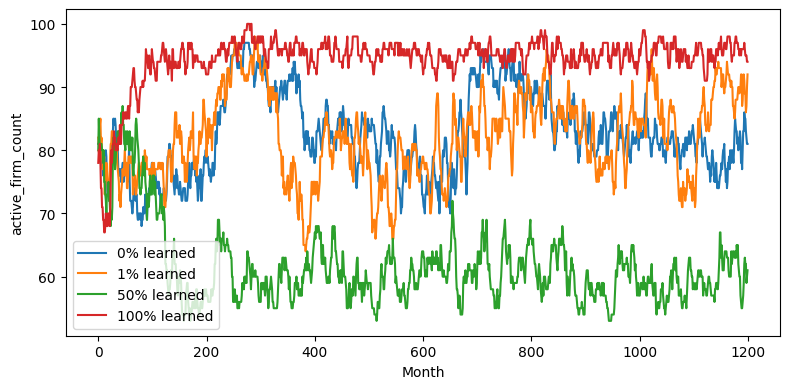

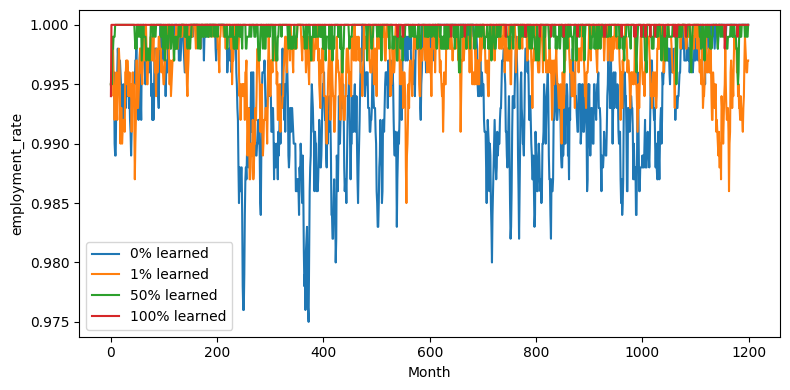

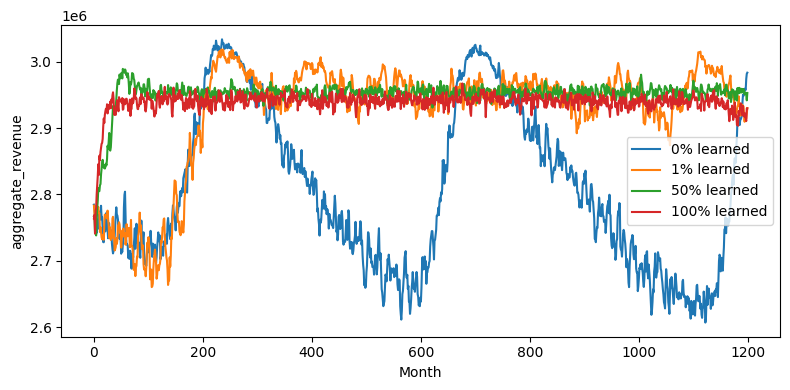

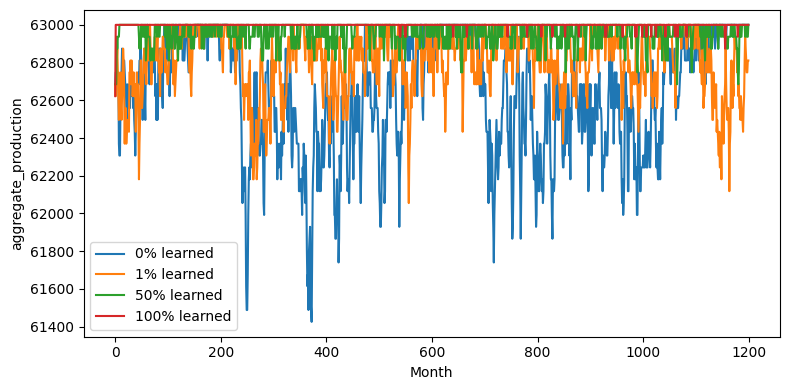

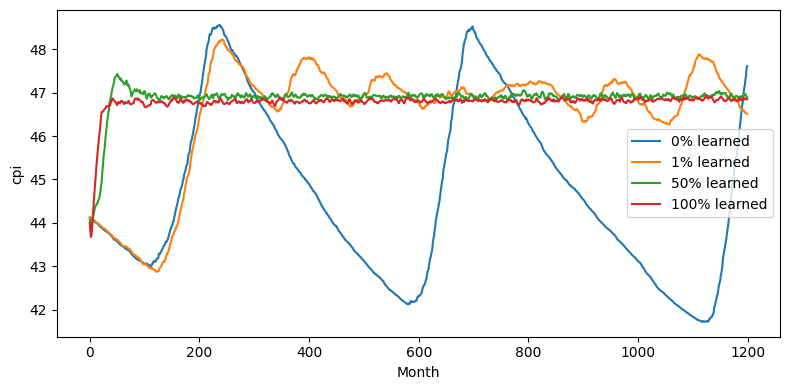

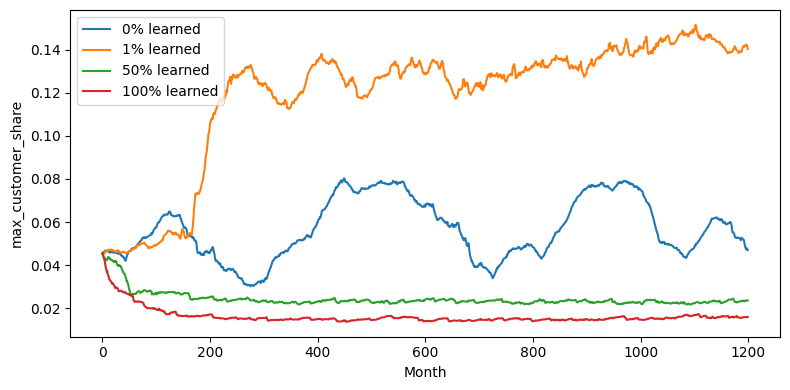

In [88]:
def plot_scenarios(quick, stat_name):
    plt.figure(figsize=(8, 4))
    for adoption_rate, stats in quick.items():
        y = np.asarray(stats[stat_name], dtype=float)
        plt.plot(y, label=f"{int(adoption_rate * 100)}% learned")
    plt.xlabel("Month")
    plt.ylabel(stat_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_scenarios(pilot, "active_firm_count")
plot_scenarios(pilot, "employment_rate")
plot_scenarios(pilot, "aggregate_revenue")
plot_scenarios(pilot, "aggregate_production")
plot_scenarios(pilot, "cpi")
plot_scenarios(pilot, "max_customer_share")

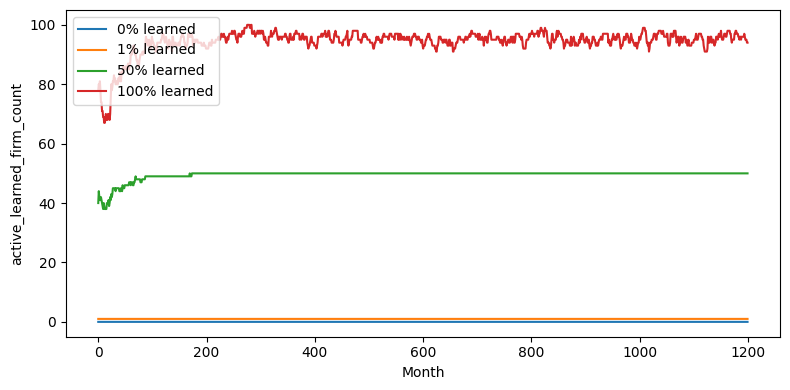

In [89]:
plot_scenarios(pilot, "active_learned_firm_count")

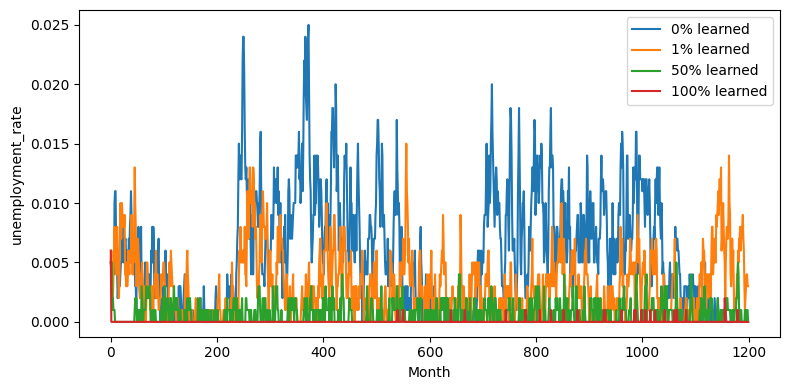

In [92]:
plot_scenarios(pilot, "unemployment_rate")

## True runs

In [9]:
def run_adoption_grid_safe(
    model_seeds=range(20, 40),
    run_seeds=range(100, 110),
    adoption_rates=(0.0, 0.01, 0.50, 1.0),
    years=100,
    out_path="macro_adoption_results.pkl",
):
    out_path = Path('../stats') / Path(out_path)

    if out_path.exists():
        with open(out_path, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}

    for model_seed in model_seeds:
        base_model = load_burned_in_model(model_seed)

        for adoption_rate in adoption_rates:
            for run_seed in run_seeds:
                key = (model_seed, run_seed, adoption_rate)

                if key in results:
                    print(f"Skipping existing {key}")
                    continue

                stats, final_model, learning_firms = simulate_adoption(
                    years=years,
                    model_seed=model_seed,
                    run_seed=run_seed,
                    adoption_rate=adoption_rate,
                    base_model=base_model,
                )

                results[key] = {
                    "model_seed": model_seed,
                    "run_seed": run_seed,
                    "adoption_rate": adoption_rate,
                    "years": years,
                    "n_learning_firms": len(learning_firms),
                    "stats": stats,
                }

                with open(out_path, "wb") as f:
                    pickle.dump(results, f)

                print(
                    f"Saved model_seed={model_seed}, "
                    f"run_seed={run_seed}, "
                    f"adoption_rate={adoption_rate}, "
                    f"n_learning_firms={len(learning_firms)}"
                )

    return results

In [ ]:
macro_results = run_adoption_grid_safe(
    model_seeds=range(20, 40),
    run_seeds=range(100, 110),
    adoption_rates=(0.0, 0.01, 0.50, 1.0),
    years=100,
    out_path="macro_adoption_results_20x10x4.pkl",
)

Loading macro model seed 20
Saved model_seed=20, run_seed=100, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=101, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=102, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=103, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=104, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=105, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=106, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=107, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=108, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=109, adoption_rate=0.0, n_learning_firms=0
Saved model_seed=20, run_seed=100, adoption_rate=0.01, n_learning_firms=1
Saved model_seed=20, run_seed=101, adoption_rate=0.01, n_learning_firms=1
Saved model_seed=20, run_seed=102, adoption_rate=0.01, n_learning_firms=1
Saved model_seed=20,

## Load simulation data

In [8]:
with open('../stats/macro_adoption_results_20x10x4.pkl', "rb") as f:
    macro_results = pickle.load(f)

## Data analysis

In [9]:
def monthly_to_yearly_mean(values, months_per_year=12):
    values = np.asarray(values, dtype=float)

    # Trim incomplete final year if needed
    n_complete_years = len(values) // months_per_year
    values = values[:n_complete_years * months_per_year]

    yearly = values.reshape(n_complete_years, months_per_year).mean(axis=1)
    return yearly

def plot_trajectories(stat_name, model_seed=20, run_seed=100):
    plt.figure(figsize=(8, 4))
    for adoption_rate in [0.0, 0.01, 0.5, 1.0]:
        y = np.asarray(macro_results[(model_seed, run_seed, adoption_rate)]['stats'][stat_name], dtype=float)
        plt.plot(y, label=f"{int(adoption_rate * 100)}% learned")
    plt.title(f"{stat_name} across adoption scenarios for model seed {model_seed} and run seed {run_seed}")
    plt.xlabel("Month")
    plt.ylabel(stat_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_yearly_trajectories(stat_name, model_seed=20, run_seed=100):
    plt.figure(figsize=(8, 4))
    for adoption_rate in [0.0, 0.01, 0.5, 1.0]:
        y = monthly_to_yearly_mean(np.asarray(macro_results[(model_seed, run_seed, adoption_rate)]['stats'][stat_name], dtype=float))
        plt.plot(y, label=f"{int(adoption_rate * 100)}% learned")
    plt.title(f"{stat_name} across adoption scenarios for model seed {model_seed} and run seed {run_seed}")
    plt.xlabel("Year")
    plt.ylabel(stat_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
macro_results[(20, 101, 0.0)]['stats'].keys()

dict_keys(['active_firm_count', 'bankrupt_firm_count', 'employment_rate', 'unemployment_rate', 'open_position_count', 'open_position_rate', 'aggregate_production', 'aggregate_revenue', 'nominal_output', 'real_output', 'aggregate_profit', 'real_aggregate_profit', 'aggregate_demand', 'aggregate_inventories', 'inventory_to_demand', 'cpi', 'mean_active_price', 'median_active_price', 'mean_active_wage', 'median_active_wage', 'median_active_employees', 'median_active_customers', 'mean_active_employees', 'mean_active_customers', 'max_employee_share', 'max_customer_share', 'max_revenue_share', 'employee_hhi', 'customer_hhi', 'revenue_hhi', 'learned_firm_count', 'active_learned_firm_count', 'learned_employee_share', 'learned_customer_share', 'learned_revenue_share', 'learned_profit_share', 'learned_production_share', 'learned_aggregate_profit', 'learned_aggregate_revenue', 'learned_aggregate_production', 'learned_aggregate_inventories', 'mean_learned_price_adjustment', 'mean_learned_wage_adjust

In [11]:
np.nanstd(macro_results[(20, 100, 0.00)]['stats']['employment_rate'], ddof=0)

np.float64(0.0049451962521443234)

In [12]:
(
    np.mean(macro_results[(20, 100, 0.00)]['stats']['share_learned_hr_fire']),
    np.mean(macro_results[(20, 100, 0.00)]['stats']['share_learned_hr_no_action']),
    np.mean(macro_results[(20, 100, 0.00)]['stats']['share_learned_hr_hire']),
    np.mean(macro_results[(20, 100, 0.01)]['stats']['share_learned_hr_fire']),
    np.mean(macro_results[(20, 100, 0.01)]['stats']['share_learned_hr_no_action']),
    np.mean(macro_results[(20, 100, 0.01)]['stats']['share_learned_hr_hire']),
    np.mean(macro_results[(20, 100, 0.5)]['stats']['share_learned_hr_fire']),
    np.mean(macro_results[(20, 100, 0.5)]['stats']['share_learned_hr_no_action']),
    np.mean(macro_results[(20, 100, 0.5)]['stats']['share_learned_hr_hire']),
    np.mean(macro_results[(20, 100, 1.0)]['stats']['share_learned_hr_fire']),
    np.mean(macro_results[(20, 100, 1.0)]['stats']['share_learned_hr_no_action']),
    np.mean(macro_results[(20, 100, 1.0)]['stats']['share_learned_hr_hire']),
)

(np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0014666666666666667),
 np.float64(0.9985333333333334),
 np.float64(0.0002583333333333334),
 np.float64(0.04078333333333334),
 np.float64(0.9589583333333334))

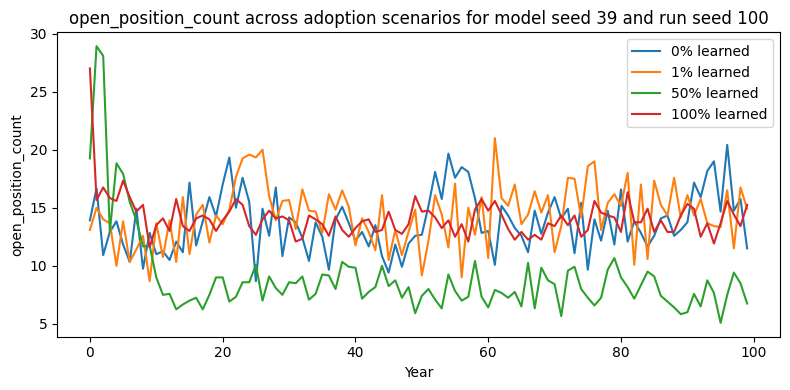

In [13]:
plot_yearly_trajectories("open_position_count", model_seed=39, run_seed=100)
#plot_trajectories("open_position_rate", model_seed=20, run_seed=100)

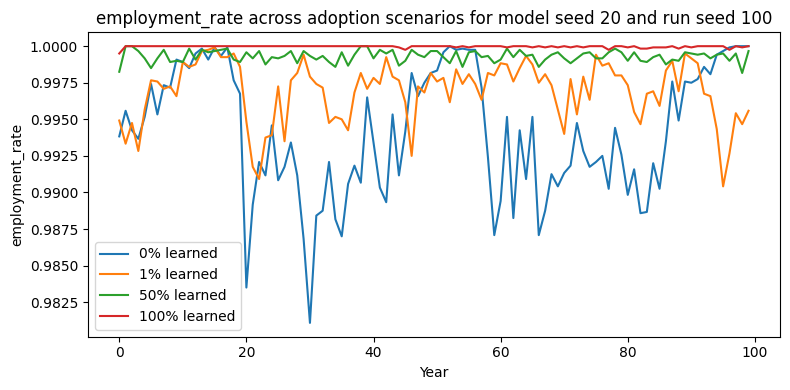

In [14]:
plot_yearly_trajectories("employment_rate", model_seed=20, run_seed=100)

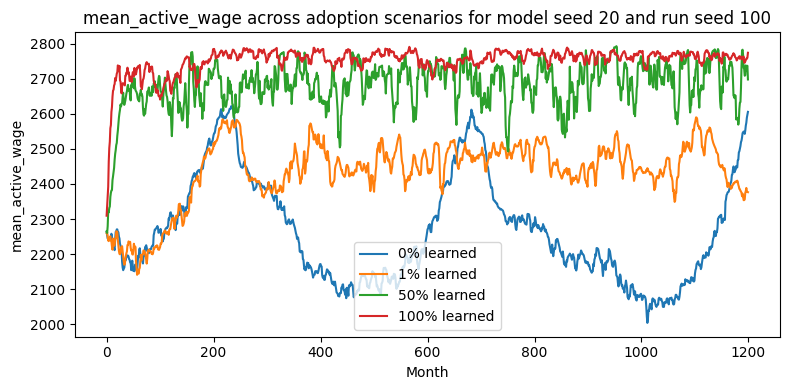

In [15]:
plot_trajectories("mean_active_wage", model_seed=20, run_seed=100)

In [16]:
def summarize_inventory_dynamics(stats):
    x = np.asarray(stats["inventory_to_demand"], dtype=float)
    months = np.arange(len(x))

    return {
        "mean_inventory_to_demand_full": np.nanmean(x),
        "mean_inventory_to_demand_last_50y": np.nanmean(x[600:]),
        "final_inventory_to_demand": x[-1],
        "inventory_to_demand_slope": np.polyfit(months[np.isfinite(x)], x[np.isfinite(x)], 1)[0],
    }

summarize_inventory_dynamics(macro_results[(20, 100, 1.0)]['stats'])

{'mean_inventory_to_demand_full': np.float64(1.0239335769730344),
 'mean_inventory_to_demand_last_50y': np.float64(1.561405879217248),
 'final_inventory_to_demand': np.float64(2.4185043565471673),
 'inventory_to_demand_slope': np.float64(0.001812023925746139)}

In [20]:
# -----------------------------
# Helpers
# -----------------------------

def window_values(values, start_month=0, end_month=None):
    arr = np.asarray(values, dtype=float)
    if end_month is None:
        end_month = len(arr)
    return arr[start_month:end_month]


def summarize_time_mean(stats, key, start_month=0, end_month=None):
    if key not in stats:
        return np.nan
    values = window_values(stats[key], start_month=start_month, end_month=end_month)
    if len(values) == 0:
        return np.nan
    return float(np.nanmean(values))


def make_run_level_macro_df(
    macro_results,
    start_month=0,
    end_month=None,
):
    """
    Creates one row per simulation run.
    
    start_month/end_month allow different analysis windows:
    - full 100 years: start_month=0, end_month=None
    - last 50 years: start_month=600, end_month=None
    - first 10 years: start_month=0, end_month=120
    """
    rows = []

    for key, result in macro_results.items():
        stats = result["stats"]

        row = {
            "model_seed": result.get("model_seed", key[0]),
            "run_seed": result.get("run_seed", key[1]),
            "adoption_rate": result.get("adoption_rate", key[2]),
            "n_learning_firms": result.get("n_learning_firms", np.nan),

            # Table 7 candidates
            "mean_unemployment_rate": summarize_time_mean(
                stats, "unemployment_rate", start_month, end_month
            ),
            "mean_real_output": summarize_time_mean(
                stats, "real_output", start_month, end_month
            ),
            "mean_aggregate_production": summarize_time_mean(
                stats, "aggregate_production", start_month, end_month
            ),
            "mean_nominal_output": summarize_time_mean(
                stats, "nominal_output", start_month, end_month
            ),
            "mean_inventory_to_demand": summarize_time_mean(
                stats, "inventory_to_demand", start_month, end_month
            ),
            "mean_household_unsatisfied_demand": summarize_time_mean(
                stats, "mean_household_unsatisfied_demand", start_month, end_month
            ),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def aggregate_by_adoption(run_df):
    """
    Aggregation logic:
    1. Average across run seeds within each model_seed and adoption_rate.
    2. Average those model-seed means across model seeds.

    This prevents model seeds with more completed run seeds from receiving more weight.
    """
    value_cols = [
        c for c in run_df.columns
        if c not in ["model_seed", "run_seed", "adoption_rate", "n_learning_firms"]
    ]

    seed_level = (
        run_df
        .groupby(["model_seed", "adoption_rate"], as_index=False)[value_cols]
        .mean()
    )

    adoption_mean = (
        seed_level
        .groupby("adoption_rate")[value_cols]
        .mean()
    )

    adoption_std = (
        seed_level
        .groupby("adoption_rate")[value_cols]
        .std()
    )

    return seed_level, adoption_mean, adoption_std


def build_table_market_state(adoption_mean):
    """
    Converts adoption-level summary into thesis-table format.
    """
    metric_map = {
        "mean_unemployment_rate": "Mean unemployment rate (%)",
        "mean_real_output": "Mean real output",
        "mean_aggregate_production": "Mean aggregate production",
        "mean_nominal_output": "Mean nominal output",
        "mean_inventory_to_demand": "Mean inventory-to-demand ratio",
        "mean_household_unsatisfied_demand": "Mean household unsatisfied demand",
    }

    table = adoption_mean.rename(index=lambda x: f"{int(x * 100)}% learned")
    table = table.T
    table.index = [metric_map.get(idx, idx) for idx in table.index]

    return table


def format_table_market_state(table):
    formatted = table.copy()

    for idx in formatted.index:
        if "rate (%)" in idx:
            formatted.loc[idx] = formatted.loc[idx].astype(float).map(lambda x: f"{100 * x:.2f}")
        elif "unsatisfied demand" in idx:
            formatted.loc[idx] = formatted.loc[idx].astype(float).map(lambda x: f"{100 * x:.2f}")
        elif "inventory-to-demand" in idx:
            formatted.loc[idx] = formatted.loc[idx].astype(float).map(lambda x: f"{x:.2f}")
        else:
            formatted.loc[idx] = formatted.loc[idx].astype(float).map(lambda x: f"{x:,.0f}")

    return formatted


# Full-horizon version: months 0-1199 for 100-year runs
run_macro_df = make_run_level_macro_df(
    macro_results,
    start_month=0,
    end_month=None,
)

seed_level_macro_df, adoption_mean, adoption_std = aggregate_by_adoption(run_macro_df)

table_market_state = build_table_market_state(adoption_mean)

table_market_state_formatted = format_table_market_state(table_market_state)
table_market_state_formatted

/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/3017867393.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.54' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[idx] = formatted.loc[idx].astype(float).map(lambda x: f"{100 * x:.2f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/3017867393.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.31' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[idx] = formatted.loc[idx].astype(float).map(lambda x: f"{100 * x:.2f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/3017867393.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Va

adoption_rate,0% learned,1% learned,50% learned,100% learned
Mean unemployment rate (%),0.54,0.31,0.07,0.00
Mean real output,"62,811","62,869","62,958","62,934"
Mean aggregate production,"62,660","62,807","62,957","62,999"
Mean nominal output,"2,812,395","2,928,083","2,952,026","2,942,801"
Mean inventory-to-demand ratio,0.09,0.11,0.09,0.44
Mean household unsatisfied demand,5.31,2.12,1.01,1.30


### Labor market

In [19]:
def get_stat_series(stats, key, fallback_key=None):
    """
    Return a numeric array from stats[key], with optional fallback.
    """
    if key in stats:
        return np.asarray(stats[key], dtype=float)
    if fallback_key is not None and fallback_key in stats:
        return np.asarray(stats[fallback_key], dtype=float)
    return np.asarray([], dtype=float)


def summarize_labor_market(stats, start_month=0, end_month=None):
    """
    Summarize labor-market outcomes for one simulation run.
    """
    unemployment = get_stat_series(stats, "unemployment_rate")
    mean_wage = get_stat_series(stats, "mean_active_wage")
    median_wage = get_stat_series(stats, "median_active_wage")

    # Vacancy stats from your custom macro collector.
    vacancy_count = get_stat_series(stats, "open_position_count")
    vacancy_rate = get_stat_series(stats, "open_position_rate")

    if end_month is None:
        end_month = len(unemployment)

    def window(x):
        return x[start_month:min(end_month, len(x))]

    u = window(unemployment)
    mw = window(mean_wage)
    medw = window(median_wage)
    vc = window(vacancy_count)
    vr = window(vacancy_rate)

    return {
        "mean_unemployment_rate": np.nanmean(u),
        "std_unemployment_rate": np.nanstd(u, ddof=1),
        "mean_active_wage": np.nanmean(mw),
        "median_active_wage": np.nanmean(medw),
        "mean_vacancy_count": np.nanmean(vc),
        "mean_vacancy_rate": np.nanmean(vr),
    }


def make_labor_market_run_df(macro_results, start_month=0, end_month=None):
    """
    One row per simulation run.
    """
    rows = []

    for key, result in macro_results.items():
        stats = result["stats"]

        row = {
            "model_seed": result.get("model_seed", key[0]),
            "run_seed": result.get("run_seed", key[1]),
            "adoption_rate": result.get("adoption_rate", key[2]),
            "n_learning_firms": result.get("n_learning_firms", np.nan),
        }

        row.update(
            summarize_labor_market(
                stats,
                start_month=start_month,
                end_month=end_month,
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)


def aggregate_labor_market_by_adoption(run_df):
    """
    Aggregation:
    1. Average across run seeds within each model seed/adoption rate.
    2. Average across model seeds.
    """
    value_cols = [
        "mean_unemployment_rate",
        "std_unemployment_rate",
        "mean_active_wage",
        "median_active_wage",
        "mean_vacancy_count",
        "mean_vacancy_rate",
    ]

    seed_level = (
        run_df
        .groupby(["model_seed", "adoption_rate"], as_index=False)[value_cols]
        .mean()
    )

    adoption_summary = (
        seed_level
        .groupby("adoption_rate")[value_cols]
        .mean()
    )

    return seed_level, adoption_summary


def build_labor_market_table(adoption_summary):
    """
    Thesis-table layout.
    """
    table = adoption_summary.copy()
    table = table.rename(index=lambda x: f"{int(x * 100)}% learned")

    table = table.T.rename(index={
        "mean_unemployment_rate": "Mean unemployment rate (%)",
        "std_unemployment_rate": "Std. unemployment rate (percentage points)",
        "mean_active_wage": "Mean active-firm wage rate",
        "median_active_wage": "Mean median active-firm wage rate",
        "mean_vacancy_count": "Mean vacancy count",
        "mean_vacancy_rate": "Mean vacancy rate (%)",
    })

    return table


def format_labor_market_table(table):
    formatted = table.copy()

    for row in formatted.index:
        if "unemployment rate" in row or "vacancy rate" in row:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{100 * x:.2f}")
        elif "wage" in row:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.2f}")
        else:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:.2f}")

    return formatted


labor_run_df = make_labor_market_run_df(
    macro_results,
    start_month=0,
    end_month=None,
)

labor_seed_level_df, labor_adoption_summary = aggregate_labor_market_by_adoption(
    labor_run_df
)

labor_table = build_labor_market_table(labor_adoption_summary)
labor_table_formatted = format_labor_market_table(labor_table)

labor_table_formatted

/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/2549451312.py:129: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.54' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{100 * x:.2f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/2549451312.py:129: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.31' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{100 * x:.2f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/2549451312.py:129: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Va

adoption_rate,0% learned,1% learned,50% learned,100% learned
Mean unemployment rate (%),0.54,0.31,0.07,0.00
Std. unemployment rate (percentage points),0.45,0.27,0.09,0.01
Mean active-firm wage rate,"2,286.14","2,437.42","2,675.30","2,763.59"
Mean median active-firm wage rate,"2,329.34","2,485.43","2,773.71","2,786.43"
Mean vacancy count,13.51,14.79,8.94,14.46
Mean vacancy rate (%),16.61,18.35,14.23,15.14


In [21]:
def plot_adoption_trajectories_from_results(
    macro_results,
    model_seed,
    run_seed,
    adoption_rates=(0.0, 0.01, 0.5, 1.0),

    # metric organization
    sections=None,
    metric_labels=None,
    transform_map=None,

    # time aggregation
    aggregation="yearly",          # "monthly", "yearly", or "rolling"
    rolling_window=12,
    from_x=None,
    to_x=None,

    # layout
    col_wrap=2,
    panel_height=4.0,
    aspect=2.0,

    # titles
    suptitle=None,
    show_suptitle=True,
    show_section_titles=True,
    show_metric_titles=True,

    # appearance
    marker=None,
    linewidth=1,

    # legend
    show_legend=True,

    # download
    download=False,
    filename="macro_trajectories.png",
):
    """
    Plot macro trajectories across adoption scenarios for one model_seed + run_seed.

    Expected macro_results format:
        macro_results[(model_seed, run_seed, adoption_rate)] = {
            "model_seed": ...,
            "run_seed": ...,
            "adoption_rate": ...,
            "stats": stats_dict,
        }

    Also supports results where the key is different but each value contains:
        result["model_seed"], result["run_seed"], result["adoption_rate"], result["stats"]
    """

    metric_labels = metric_labels or {}
    transform_map = transform_map or {}

    # ---------------- extract scenario stats ----------------
    scenario_stats = {}

    for adoption_rate in adoption_rates:
        found = None

        # Case 1: dictionary keyed by (model_seed, run_seed, adoption_rate)
        key = (model_seed, run_seed, adoption_rate)
        if key in macro_results:
            found = macro_results[key]

        # Case 2: search through values
        if found is None:
            for _, result in macro_results.items():
                if (
                    result.get("model_seed") == model_seed
                    and result.get("run_seed") == run_seed
                    and np.isclose(result.get("adoption_rate"), adoption_rate)
                ):
                    found = result
                    break

        if found is None:
            raise KeyError(
                f"No result found for model_seed={model_seed}, "
                f"run_seed={run_seed}, adoption_rate={adoption_rate}"
            )

        scenario_stats[adoption_rate] = found["stats"]

    # ---------------- helper functions ----------------
    def convert_series(values):
        arr = np.asarray(values, dtype=float)

        if aggregation == "monthly":
            x = np.arange(1, len(arr) + 1)
            x_label = "month"
            return x, arr, x_label

        if aggregation == "yearly":
            n_years = len(arr) // 12
            arr = arr[:n_years * 12]

            if n_years == 0:
                raise ValueError("Not enough monthly observations to aggregate yearly.")

            arr = arr.reshape(n_years, 12).mean(axis=1)
            x = np.arange(1, len(arr) + 1)
            x_label = "year"
            return x, arr, x_label

        if aggregation == "rolling":
            arr = (
                pd.Series(arr)
                .rolling(window=rolling_window, min_periods=1)
                .mean()
                .to_numpy()
            )
            x = np.arange(1, len(arr) + 1)
            x_label = "month"
            return x, arr, x_label

        raise ValueError("aggregation must be one of: 'monthly', 'yearly', or 'rolling'.")

    def _title_row_mask(section_specs):
        mask = []
        for _, _, nrows, _ in section_specs:
            mask.append(True)
            mask.extend([False] * nrows)
        return mask

    # ---------------- determine available metrics ----------------
    all_available_metrics = set()

    for stats in scenario_stats.values():
        for k, v in stats.items():
            if isinstance(v, (list, tuple, np.ndarray)):
                all_available_metrics.add(k)

    if sections is None:
        sections = {"Metrics": sorted(all_available_metrics)}
    else:
        sections = {
            title: [m for m in metrics if m in all_available_metrics]
            for title, metrics in sections.items()
        }
        sections = {
            title: metrics
            for title, metrics in sections.items()
            if metrics
        }

    if not sections:
        raise ValueError("No valid metrics found in sections.")

    metrics_to_plot = [
        metric
        for metrics in sections.values()
        for metric in metrics
    ]

    # ---------------- build long dataframe ----------------
    long_parts = []
    x_label = None

    for adoption_rate, stats in scenario_stats.items():
        adoption_label = f"{int(adoption_rate * 100)}% adoption"

        for metric in metrics_to_plot:
            if metric not in stats:
                continue

            x, y, x_label = convert_series(stats[metric])

            if metric in transform_map:
                y = transform_map[metric](y)

            df = pd.DataFrame({
                x_label: x,
                "metric": metric,
                "value": y,
                "adoption": adoption_label,
                "adoption_rate": adoption_rate,
            })

            long_parts.append(df)

    if not long_parts:
        raise ValueError("No plottable metric series found.")

    long_df = pd.concat(long_parts, ignore_index=True)

    if from_x is not None:
        long_df = long_df[long_df[x_label] >= from_x]

    if to_x is not None:
        long_df = long_df[long_df[x_label] <= to_x]

    # ---------------- style: matched to earlier function ----------------
    plt.rcdefaults()
    plt.rcParams.update({
        "figure.titlesize": 28,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 18,
    })

    adoption_rates_sorted = sorted(scenario_stats.keys())
    adoption_labels = [f"{int(a * 100)}% adoption" for a in adoption_rates_sorted]

    palette = sns.color_palette(n_colors=len(adoption_labels))
    adoption_color_map = dict(zip(adoption_labels, palette))

    # ---------------- layout bookkeeping ----------------
    section_specs = []
    total_plot_rows = 0
    max_cols = 0

    for section_title, metrics in sections.items():
        ncols = min(col_wrap, len(metrics))
        nrows = math.ceil(len(metrics) / ncols)
        section_specs.append((section_title, metrics, nrows, ncols))
        total_plot_rows += nrows
        max_cols = max(max_cols, ncols)

    title_row_count = len(section_specs) if show_section_titles else 0
    total_rows = total_plot_rows + title_row_count

    fig_width = max_cols * panel_height * aspect
    fig_height = total_plot_rows * panel_height + (0.55 * title_row_count) + 1.0

    fig = plt.figure(figsize=(fig_width, fig_height))

    if show_section_titles:
        height_ratios = [
            0.22 if row_is_title else 1.0
            for row_is_title in _title_row_mask(section_specs)
        ]
    else:
        height_ratios = [1.0] * total_rows

    gs = GridSpec(
        total_rows,
        max_cols,
        figure=fig,
        height_ratios=height_ratios,
    )

    if suptitle is None:
        suptitle = (
            f"Macroeconomic trajectories across adoption scenarios "
            f"(model seed {model_seed}, run seed {run_seed})"
        )

    if show_suptitle:
        fig.suptitle(suptitle, y=0.995)

    # ---------------- draw ----------------
    current_row = 0
    first_ax = None
    legend_handles = None
    legend_labels = None

    for section_title, metrics, nrows, ncols in section_specs:
        if show_section_titles:
            title_ax = fig.add_subplot(gs[current_row, :])
            title_ax.axis("off")
            title_ax.text(
                0.5,
                0.5,
                section_title,
                ha="center",
                va="center",
                fontsize=22,
            )
            current_row += 1

        section_axes = []

        for i, metric in enumerate(metrics):
            r = i // ncols
            c = i % ncols

            ax = fig.add_subplot(
                gs[current_row + r, c],
                sharex=first_ax if first_ax is not None else None,
            )

            if first_ax is None:
                first_ax = ax

            metric_df = long_df[long_df["metric"] == metric]

            sns.lineplot(
                data=metric_df,
                x=x_label,
                y="value",
                hue="adoption",
                hue_order=adoption_labels,
                marker=marker,
                linewidth=linewidth,
                ax=ax,
                legend=True,
                palette=adoption_color_map,
            )

            handles, labels = ax.get_legend_handles_labels()
            if handles and labels and legend_handles is None:
                legend_handles, legend_labels = handles, labels

            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

            display_name = metric_labels.get(metric, metric.replace("_", " ").title())

            if show_metric_titles:
                ax.set_title(display_name, pad=4)
            else:
                ax.set_title("")

            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

            section_axes.append(ax)

        # x-label only on bottom row of the section
        for ax in section_axes[max(0, len(metrics) - ncols):]:
            ax.set_xlabel(x_label)
            ax.tick_params(axis="x", labelbottom=True)

        # blank axes for incomplete grid cells
        for j in range(len(metrics), nrows * ncols):
            r = j // ncols
            c = j % ncols
            blank_ax = fig.add_subplot(gs[current_row + r, c])
            blank_ax.axis("off")

        current_row += nrows

    if show_legend and legend_handles is not None:
        legend_y = 0.975 if show_suptitle else 0.995
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, legend_y),
            frameon=False,
        )

    top_rect = 0.94 if (show_suptitle or show_legend) else 0.985
    fig.tight_layout(rect=[0, 0, 1, top_rect])

    if download:
        plt.savefig(f'../imgs/{filename}', dpi=300, bbox_inches="tight")

    plt.show()

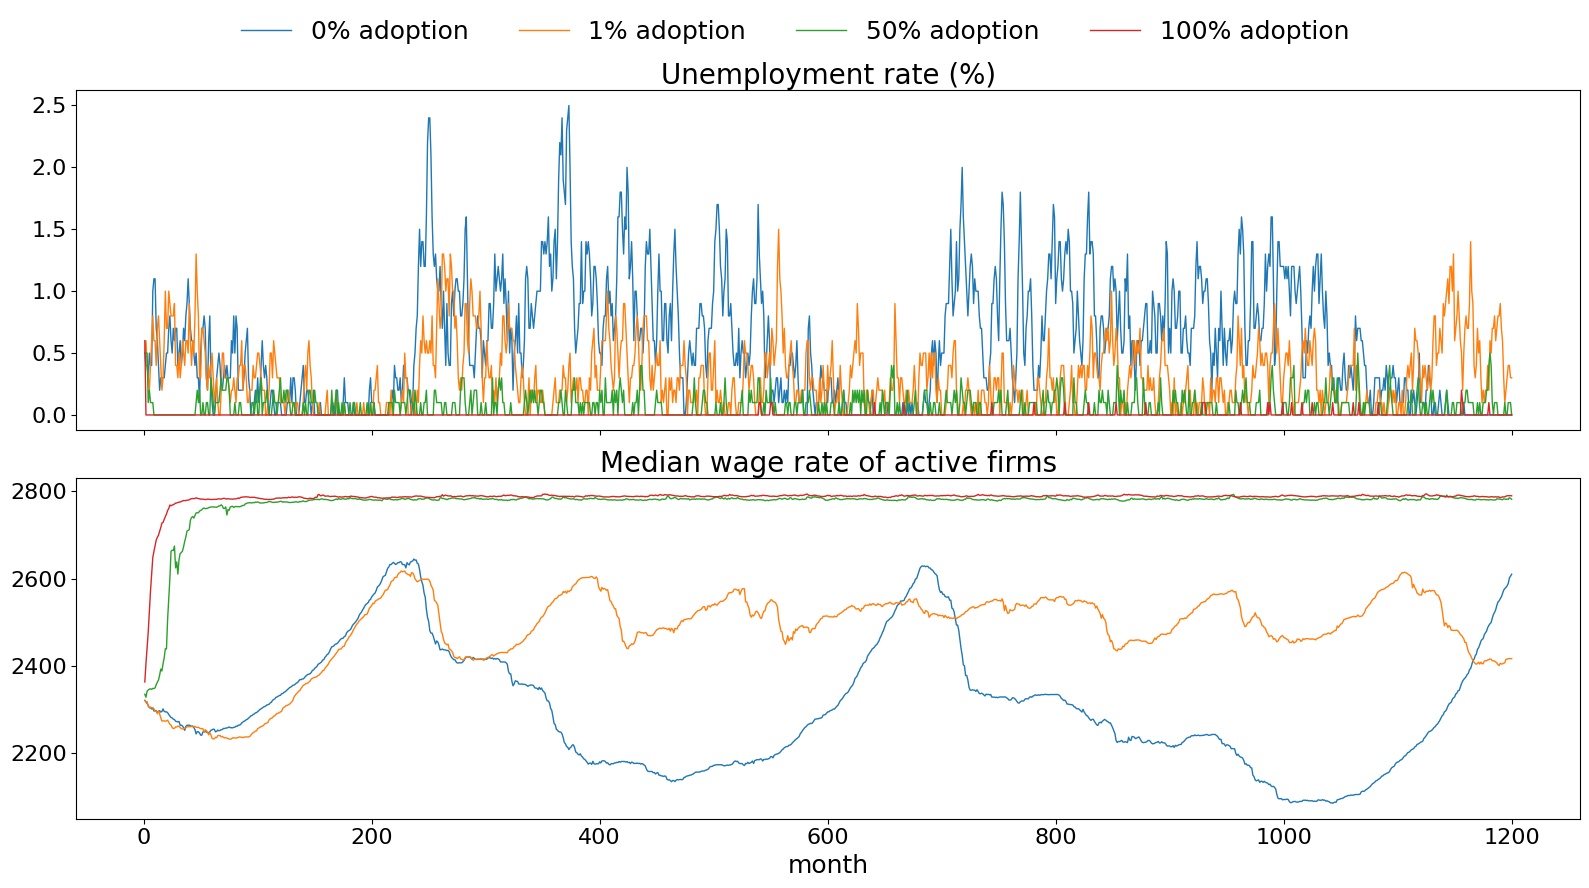

In [23]:
labor_sections = {
    "Labor market": [
        "unemployment_rate",
        "median_active_wage",
    ]
}

labor_metric_labels = {
    "unemployment_rate": "Unemployment rate (%)",
    "median_active_wage": "Median wage rate of active firms",
}

labor_transform_map = {
    "unemployment_rate": lambda x: 100 * x,
    "open_position_rate": lambda x: 100 * x,
}

plot_adoption_trajectories_from_results(
    macro_results=macro_results,
    model_seed=20,
    run_seed=100,
    sections=labor_sections,
    metric_labels=labor_metric_labels,
    transform_map=labor_transform_map,
    aggregation="monthly",
    panel_height=4.0,
    aspect=4.0,
    col_wrap=1,
    download=True,
    show_suptitle=False,
    show_section_titles=False,
    filename="fig_7.pdf",
)

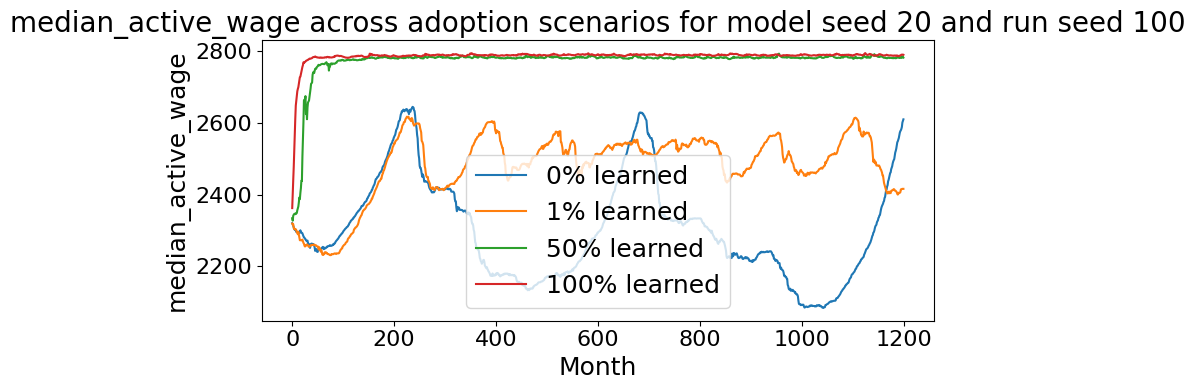

In [24]:
plot_trajectories("median_active_wage", model_seed=20, run_seed=100)

### Goods market

In [25]:
def get_stat_series(stats, key, fallback_key=None):
    if key in stats:
        return np.asarray(stats[key], dtype=float)
    if fallback_key is not None and fallback_key in stats:
        return np.asarray(stats[fallback_key], dtype=float)
    return np.asarray([], dtype=float)


def window_series(x, start_month=0, end_month=None):
    x = np.asarray(x, dtype=float)
    if end_month is None:
        end_month = len(x)
    return x[start_month:min(end_month, len(x))]


def safe_nanmean(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.all(np.isnan(x)):
        return np.nan
    return float(np.nanmean(x))


def safe_nanstd(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1 or np.all(np.isnan(x)):
        return np.nan
    return float(np.nanstd(x, ddof=1))


def summarize_goods_market(stats, start_month=0, end_month=None):
    """
    Summarize goods-market outcomes for one simulation run.

    Note:
    - real_output is treated as real sales / real consumption,
      because it is based on revenue deflated by CPI.
    - nominal_output is treated as nominal sales.
    """

    aggregate_production = get_stat_series(stats, "aggregate_production")
    real_sales = get_stat_series(stats, "real_sales", fallback_key="real_output")
    nominal_sales = get_stat_series(stats, "nominal_sales", fallback_key="nominal_output")
    unsat = get_stat_series(stats, "mean_household_unsatisfied_demand")
    inv_to_demand = get_stat_series(stats, "inventory_to_demand")

    median_price = get_stat_series(stats, "median_active_price")
    mean_price = get_stat_series(stats, "mean_active_price")
    cpi = get_stat_series(stats, "cpi")

    prod = window_series(aggregate_production, start_month, end_month)
    rs = window_series(real_sales, start_month, end_month)
    ns = window_series(nominal_sales, start_month, end_month)
    ud = window_series(unsat, start_month, end_month)
    itd = window_series(inv_to_demand, start_month, end_month)

    mp = window_series(median_price, start_month, end_month)
    ap = window_series(mean_price, start_month, end_month)
    cpi_w = window_series(cpi, start_month, end_month)

    # Last 50 years of a 100-year simulation = months 600 onward.
    # This is useful for persistent inventory buildup.
    itd_late = window_series(inv_to_demand, 600, None)

    return {
        "mean_aggregate_production": safe_nanmean(prod),
        "mean_real_sales": safe_nanmean(rs),
        "mean_nominal_sales": safe_nanmean(ns),
        "mean_household_unsatisfied_demand": safe_nanmean(ud),
        "mean_inventory_to_demand": safe_nanmean(itd),
        "mean_inventory_to_demand_last_50y": safe_nanmean(itd_late),
        "final_inventory_to_demand": float(inv_to_demand[-1]) if len(inv_to_demand) else np.nan,

        "mean_median_goods_price": safe_nanmean(mp),
        "std_median_goods_price": safe_nanstd(mp),
        "mean_goods_price": safe_nanmean(ap),
        "mean_cpi": safe_nanmean(cpi_w),
    }


def make_goods_market_run_df(macro_results, start_month=0, end_month=None):
    """
    One row per simulation run.
    """
    rows = []

    for key, result in macro_results.items():
        stats = result["stats"]

        row = {
            "model_seed": result.get("model_seed", key[0]),
            "run_seed": result.get("run_seed", key[1]),
            "adoption_rate": result.get("adoption_rate", key[2]),
            "n_learning_firms": result.get("n_learning_firms", np.nan),
        }

        row.update(
            summarize_goods_market(
                stats,
                start_month=start_month,
                end_month=end_month,
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)


def aggregate_goods_market_by_adoption(run_df):
    """
    Aggregation:
    1. Average across run seeds within each model_seed/adoption_rate.
    2. Average across model seeds.
    """
    value_cols = [
        "mean_aggregate_production",
        "mean_real_sales",
        "mean_nominal_sales",
        "mean_household_unsatisfied_demand",
        "mean_inventory_to_demand",
        "mean_inventory_to_demand_last_50y",
        "final_inventory_to_demand",
        "mean_median_goods_price",
        "std_median_goods_price",
        "mean_goods_price",
        "mean_cpi",
    ]

    seed_level = (
        run_df
        .groupby(["model_seed", "adoption_rate"], as_index=False)[value_cols]
        .mean()
    )

    adoption_summary = (
        seed_level
        .groupby("adoption_rate")[value_cols]
        .mean()
    )

    return seed_level, adoption_summary


def build_goods_market_table(adoption_summary):
    """
    Thesis-table layout.
    """
    table = adoption_summary.copy()
    table = table.rename(index=lambda x: f"{int(x * 100)}% adoption")

    table = table.T.rename(index={
        "mean_aggregate_production": "Mean aggregate production",
        "mean_real_sales": "Mean real sales",
        "mean_nominal_sales": "Mean nominal sales",
        "mean_household_unsatisfied_demand": "Mean household unsatisfied demand (%)",
        "mean_inventory_to_demand": "Mean inventory-to-demand ratio",
        "mean_inventory_to_demand_last_50y": "Mean inventory-to-demand ratio (last 50 years)",
        "final_inventory_to_demand": "Final inventory-to-demand ratio",
        "mean_median_goods_price": "Mean median goods price",
        "std_median_goods_price": "Std. median goods price",
        "mean_goods_price": "Mean goods price",
        "mean_cpi": "Mean CPI",
    })

    return table


def format_goods_market_table(table):
    formatted = table.copy()

    for row in formatted.index:
        if "unsatisfied demand" in row:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{100 * x:.2f}")
        elif "ratio" in row:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:.2f}")
        elif "price" in row or "CPI" in row:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.2f}")
        else:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.0f}")

    return formatted

In [26]:
goods_run_df = make_goods_market_run_df(
    macro_results,
    start_month=0,
    end_month=None,
)

goods_seed_level_df, goods_adoption_summary = aggregate_goods_market_by_adoption(
    goods_run_df
)

goods_table = build_goods_market_table(goods_adoption_summary)
goods_table_formatted = format_goods_market_table(goods_table)

goods_table_formatted

/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/1132359056.py:179: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '62,660' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.0f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/1132359056.py:179: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '62,807' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.0f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/1132359056.py:179: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6

adoption_rate,0% adoption,1% adoption,50% adoption,100% adoption
Mean aggregate production,"62,660","62,807","62,957","62,999"
Mean real sales,"62,811","62,869","62,958","62,934"
Mean nominal sales,"2,812,395","2,928,083","2,952,026","2,942,801"
Mean household unsatisfied demand (%),5.31,2.12,1.01,1.30
Mean inventory-to-demand ratio,0.09,0.11,0.09,0.44
Mean inventory-to-demand ratio (last 50 years),0.09,0.11,0.11,0.68
Final inventory-to-demand ratio,0.09,0.11,0.13,1.02
Mean median goods price,45.00,46.74,46.80,46.66
Std. median goods price,2.05,1.04,0.32,0.26
Mean goods price,44.92,46.69,47.10,46.92


In [27]:
def get_stat_series(stats, key):
    if key not in stats:
        return np.asarray([], dtype=float)
    return np.asarray(stats[key], dtype=float)


def safe_nanmean(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.all(np.isnan(x)):
        return np.nan
    return float(np.nanmean(x))


def safe_nanstd(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1 or np.all(np.isnan(x)):
        return np.nan
    return float(np.nanstd(x, ddof=1))


def safe_div(num, denom):
    if denom == 0 or np.isnan(denom):
        return np.nan
    return num / denom


def window_series(x, start_month=0, end_month=None):
    x = np.asarray(x, dtype=float)
    if end_month is None:
        end_month = len(x)
    return x[start_month:min(end_month, len(x))]


def summarize_available_price_diagnostics(
    stats,
    start_month=0,
    end_month=None,
    lambda_technology=3,
    month_length=21,
):
    """
    Uses only currently collected macro stats.
    Cannot identify learned-firm price directly.
    """

    cpi = window_series(get_stat_series(stats, "cpi"), start_month, end_month)
    mean_price = window_series(get_stat_series(stats, "mean_active_price"), start_month, end_month)
    median_price = window_series(get_stat_series(stats, "median_active_price"), start_month, end_month)

    mean_wage = window_series(get_stat_series(stats, "mean_active_wage"), start_month, end_month)
    median_wage = window_series(get_stat_series(stats, "median_active_wage"), start_month, end_month)

    learned_revenue_share = window_series(get_stat_series(stats, "learned_revenue_share"), start_month, end_month)
    learned_customer_share = window_series(get_stat_series(stats, "learned_customer_share"), start_month, end_month)
    learned_employee_share = window_series(get_stat_series(stats, "learned_employee_share"), start_month, end_month)

    active_firm_count = window_series(get_stat_series(stats, "active_firm_count"), start_month, end_month)
    active_learned_firm_count = window_series(get_stat_series(stats, "active_learned_firm_count"), start_month, end_month)

    # Approximate marginal cost using aggregate median/mean wage statistics.
    # This is not firm-level exact, but useful as a system-level proxy.
    median_implied_mc = median_wage / (lambda_technology * month_length)
    mean_implied_mc = mean_wage / (lambda_technology * month_length)

    return {
        "mean_cpi": safe_nanmean(cpi),
        "std_cpi": safe_nanstd(cpi),

        "mean_active_price": safe_nanmean(mean_price),
        "mean_median_active_price": safe_nanmean(median_price),
        "std_median_active_price": safe_nanstd(median_price),

        "mean_active_wage": safe_nanmean(mean_wage),
        "mean_median_active_wage": safe_nanmean(median_wage),
        "std_median_active_wage": safe_nanstd(median_wage),

        "mean_implied_marginal_cost_from_median_wage": safe_nanmean(median_implied_mc),
        "mean_implied_marginal_cost_from_mean_wage": safe_nanmean(mean_implied_mc),

        "median_price_to_implied_mc": safe_nanmean(median_price / median_implied_mc),
        "mean_price_to_implied_mc": safe_nanmean(mean_price / mean_implied_mc),

        "cpi_to_median_price": safe_nanmean(cpi / median_price),
        "cpi_to_mean_price": safe_nanmean(cpi / mean_price),

        "mean_learned_revenue_share": safe_nanmean(learned_revenue_share),
        "mean_learned_customer_share": safe_nanmean(learned_customer_share),
        "mean_learned_employee_share": safe_nanmean(learned_employee_share),

        "mean_active_firm_count": safe_nanmean(active_firm_count),
        "mean_active_learned_firm_count": safe_nanmean(active_learned_firm_count),
    }


def make_available_price_diag_run_df(
    macro_results,
    start_month=0,
    end_month=None,
    lambda_technology=3,
    month_length=21,
):
    rows = []

    for key, result in macro_results.items():
        stats = result["stats"]

        row = {
            "model_seed": result.get("model_seed", key[0]),
            "run_seed": result.get("run_seed", key[1]),
            "adoption_rate": result.get("adoption_rate", key[2]),
            "n_learning_firms": result.get("n_learning_firms", np.nan),
        }

        row.update(
            summarize_available_price_diagnostics(
                stats,
                start_month=start_month,
                end_month=end_month,
                lambda_technology=lambda_technology,
                month_length=month_length,
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)


def aggregate_available_price_diag_by_adoption(run_df):
    value_cols = [
        c for c in run_df.columns
        if c not in ["model_seed", "run_seed", "adoption_rate", "n_learning_firms"]
    ]

    seed_level = (
        run_df
        .groupby(["model_seed", "adoption_rate"], as_index=False)[value_cols]
        .mean()
    )

    adoption_summary = (
        seed_level
        .groupby("adoption_rate")[value_cols]
        .mean()
    )

    return seed_level, adoption_summary


def build_available_price_diag_table(adoption_summary):
    table = adoption_summary.copy()
    table = table.rename(index=lambda x: f"{int(x * 100)}% adoption")

    table = table.T.rename(index={
        "mean_cpi": "Mean CPI",
        "std_cpi": "Std. CPI",

        "mean_active_price": "Mean active-firm goods price",
        "mean_median_active_price": "Mean median active-firm goods price",
        "std_median_active_price": "Std. median active-firm goods price",

        "mean_active_wage": "Mean active-firm wage",
        "mean_median_active_wage": "Mean median active-firm wage",
        "std_median_active_wage": "Std. median active-firm wage",

        "mean_implied_marginal_cost_from_median_wage": "Implied marginal cost from median wage",
        "mean_implied_marginal_cost_from_mean_wage": "Implied marginal cost from mean wage",

        "median_price_to_implied_mc": "Median price / implied marginal cost",
        "mean_price_to_implied_mc": "Mean price / implied marginal cost",

        "cpi_to_median_price": "CPI / median active-firm price",
        "cpi_to_mean_price": "CPI / mean active-firm price",

        "mean_learned_revenue_share": "Mean learned-firm revenue share",
        "mean_learned_customer_share": "Mean learned-firm customer share",
        "mean_learned_employee_share": "Mean learned-firm employee share",

        "mean_active_firm_count": "Mean active firm count",
        "mean_active_learned_firm_count": "Mean active learned-firm count",
    })

    return table


def format_available_price_diag_table(table):
    formatted = table.copy()

    for row in formatted.index:
        if "share" in row.lower():
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{100 * x:.2f}")
        elif "/" in row:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:.3f}")
        elif "count" in row.lower():
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:.2f}")
        else:
            formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.2f}")

    return formatted

In [28]:
price_diag_run_df = make_available_price_diag_run_df(
    macro_results,
    start_month=0,
    end_month=None,
    lambda_technology=3,
    month_length=21,
)

price_diag_seed_level_df, price_diag_adoption_summary = (
    aggregate_available_price_diag_by_adoption(price_diag_run_df)
)

price_diag_table = build_available_price_diag_table(price_diag_adoption_summary)
price_diag_table_formatted = format_available_price_diag_table(price_diag_table)

price_diag_table_formatted

/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/2365232047.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '44.78' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.2f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/2365232047.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.58' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(lambda x: f"{x:,.2f}")
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/2365232047.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.

adoption_rate,0% adoption,1% adoption,50% adoption,100% adoption
Mean CPI,44.78,46.58,46.89,46.76
Std. CPI,2.04,1.06,0.32,0.24
Mean active-firm goods price,44.92,46.69,47.10,46.92
Mean median active-firm goods price,45.00,46.74,46.80,46.66
Std. median active-firm goods price,2.05,1.04,0.32,0.26
Mean active-firm wage,"2,286.14","2,437.42","2,675.30","2,763.59"
Mean median active-firm wage,"2,329.34","2,485.43","2,773.71","2,786.43"
Std. median active-firm wage,131.74,77.39,44.57,22.85
Implied marginal cost from median wage,36.97,39.45,44.03,44.23
Implied marginal cost from mean wage,36.29,38.69,42.47,43.87


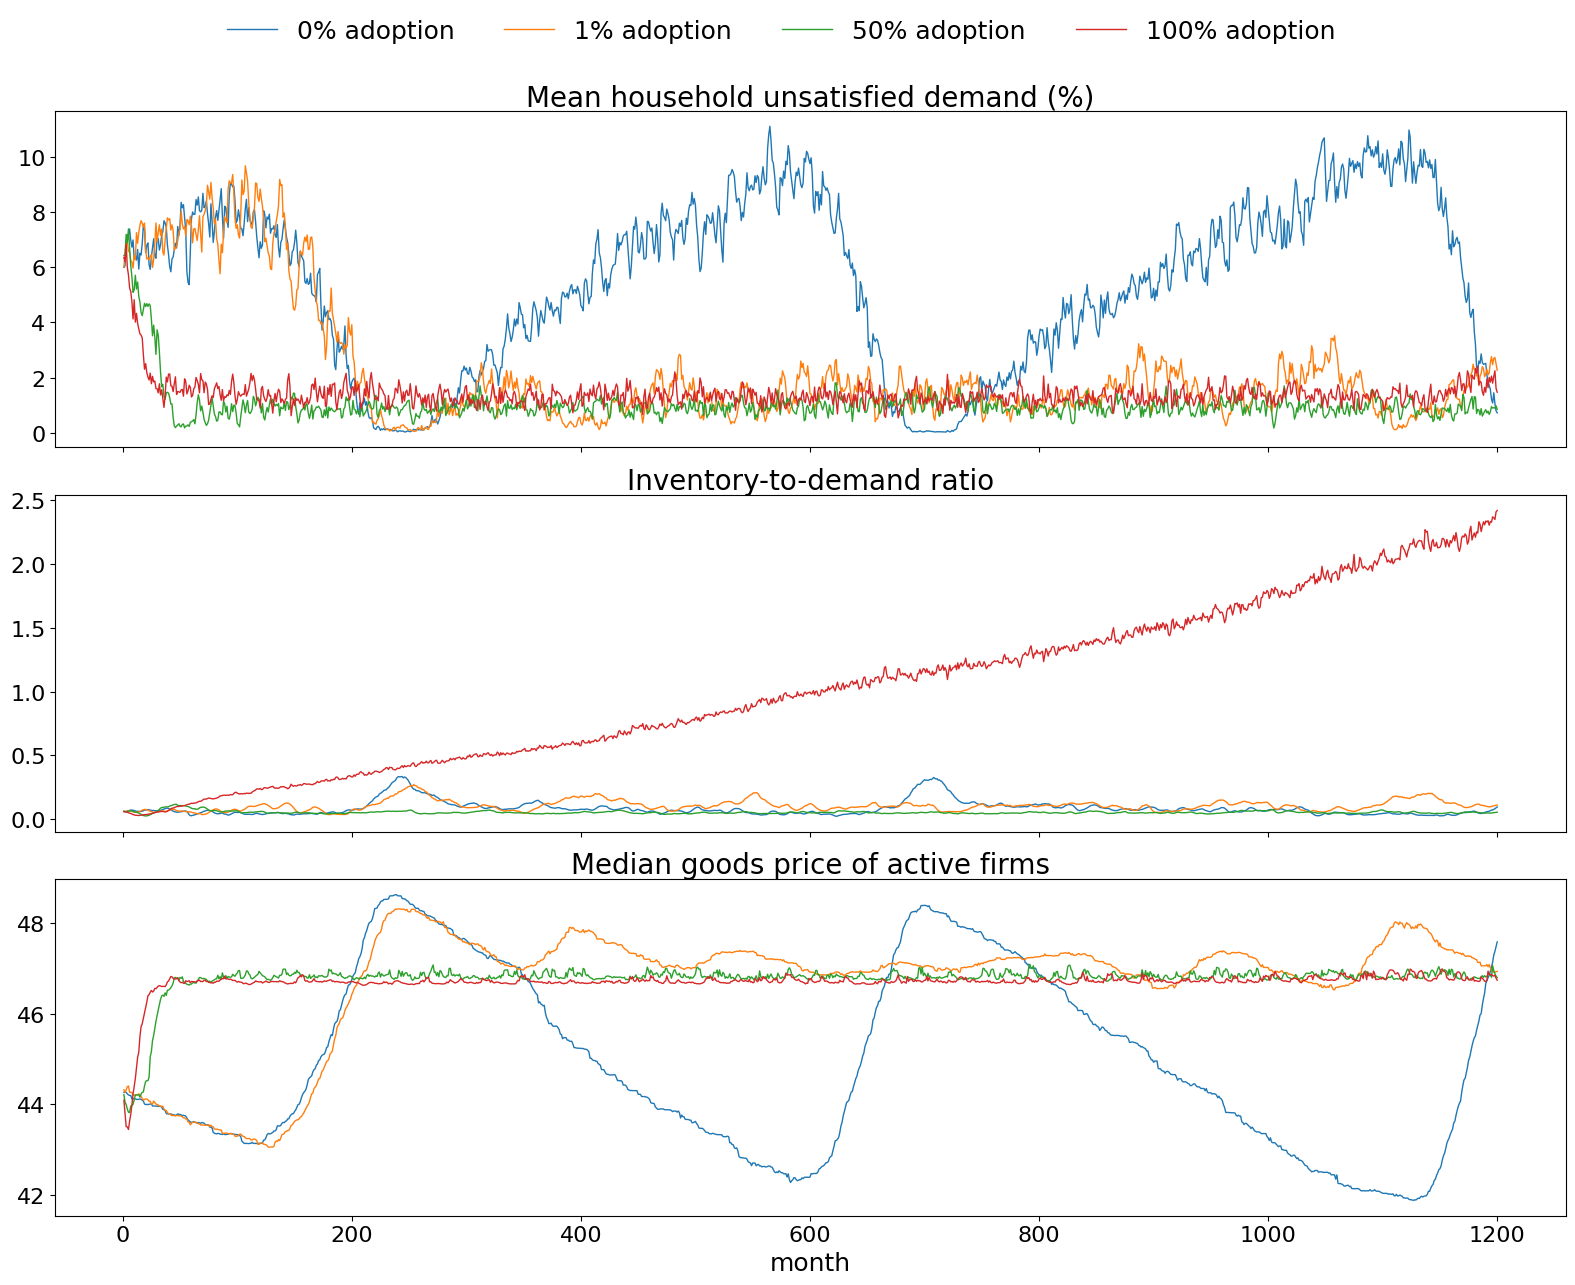

In [29]:
goods_sections = {
    "Goods market": [
        "mean_household_unsatisfied_demand",
        "inventory_to_demand",
        "median_active_price",
    ]
}

goods_metric_labels = {
    "median_active_price": "Median goods price of active firms",
    "mean_household_unsatisfied_demand": "Mean household unsatisfied demand (%)",
    "inventory_to_demand": "Inventory-to-demand ratio",
}

goods_transform_map = {
    "mean_household_unsatisfied_demand": lambda x: 100 * x,
}

plot_adoption_trajectories_from_results(
    macro_results=macro_results,
    model_seed=20,
    run_seed=100,
    sections=goods_sections,
    metric_labels=goods_metric_labels,
    transform_map=goods_transform_map,
    aggregation="monthly",   # or "yearly" if too noisy
    col_wrap=1,
    panel_height=4.0,
    aspect=4.0,
    show_suptitle=None,
    show_section_titles=False,
    download=True,
    filename="fig_8.pdf",
)

### Firm population, concentration, and profitability distribution

In [31]:
def get_stat_series(stats, key):
    if key not in stats:
        return np.asarray([], dtype=float)
    return np.asarray(stats[key], dtype=float)


def window_series(x, start_month=0, end_month=None):
    x = np.asarray(x, dtype=float)
    if end_month is None:
        end_month = len(x)
    return x[start_month:min(end_month, len(x))]


def safe_nanmean(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.all(np.isnan(x)):
        return np.nan
    return float(np.nanmean(x))


def safe_nanstd(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1 or np.all(np.isnan(x)):
        return np.nan
    return float(np.nanstd(x, ddof=1))


def safe_div_array(num, denom):
    num = np.asarray(num, dtype=float)
    denom = np.asarray(denom, dtype=float)

    n = min(len(num), len(denom))
    if n == 0:
        return np.asarray([], dtype=float)

    num = num[:n]
    denom = denom[:n]

    out = np.full(n, np.nan, dtype=float)
    valid = (denom != 0) & np.isfinite(denom)
    out[valid] = num[valid] / denom[valid]
    return out


def summarize_firm_structure(stats, start_month=0, end_month=None):
    """
    Summarize firm population, concentration, and learned-firm profitability
    for one simulation run.
    """

    active_firms = window_series(
        get_stat_series(stats, "active_firm_count"),
        start_month,
        end_month,
    )

    active_learned = window_series(
        get_stat_series(stats, "active_learned_firm_count"),
        start_month,
        end_month,
    )

    active_baseline = active_firms[:len(active_learned)] - active_learned

    learned_employee_share = window_series(
        get_stat_series(stats, "learned_employee_share"),
        start_month,
        end_month,
    )

    learned_customer_share = window_series(
        get_stat_series(stats, "learned_customer_share"),
        start_month,
        end_month,
    )

    learned_revenue_share = window_series(
        get_stat_series(stats, "learned_revenue_share"),
        start_month,
        end_month,
    )

    learned_profit_share = window_series(
        get_stat_series(stats, "learned_profit_share"),
        start_month,
        end_month,
    )

    employee_hhi = window_series(
        get_stat_series(stats, "employee_hhi"),
        start_month,
        end_month,
    )

    customer_hhi = window_series(
        get_stat_series(stats, "customer_hhi"),
        start_month,
        end_month,
    )

    revenue_hhi = window_series(
        get_stat_series(stats, "revenue_hhi"),
        start_month,
        end_month,
    )

    max_employee_share = window_series(
        get_stat_series(stats, "max_employee_share"),
        start_month,
        end_month,
    )

    max_customer_share = window_series(
        get_stat_series(stats, "max_customer_share"),
        start_month,
        end_month,
    )

    max_revenue_share = window_series(
        get_stat_series(stats, "max_revenue_share"),
        start_month,
        end_month,
    )

    aggregate_profit = window_series(
        get_stat_series(stats, "aggregate_profit"),
        start_month,
        end_month,
    )

    learned_aggregate_profit = window_series(
        get_stat_series(stats, "learned_aggregate_profit"),
        start_month,
        end_month,
    )

    profit_per_active_firm = safe_div_array(
        aggregate_profit,
        active_firms,
    )

    profit_per_active_learned_firm = safe_div_array(
        learned_aggregate_profit,
        active_learned,
    )

    return {
        # Firm population
        "mean_active_firm_count": safe_nanmean(active_firms),
        "mean_active_learned_firm_count": safe_nanmean(active_learned),
        "mean_active_baseline_firm_count": safe_nanmean(active_baseline),

        # Learned-firm market shares
        "mean_learned_employee_share": safe_nanmean(learned_employee_share),
        "mean_learned_customer_share": safe_nanmean(learned_customer_share),
        "mean_learned_revenue_share": safe_nanmean(learned_revenue_share),
        "mean_learned_profit_share": safe_nanmean(learned_profit_share),

        # Concentration
        "mean_employee_hhi": safe_nanmean(employee_hhi),
        "mean_customer_hhi": safe_nanmean(customer_hhi),
        "mean_revenue_hhi": safe_nanmean(revenue_hhi),

        # Largest-firm shares
        "mean_max_employee_share": safe_nanmean(max_employee_share),
        "mean_max_customer_share": safe_nanmean(max_customer_share),
        "mean_max_revenue_share": safe_nanmean(max_revenue_share),

        # Profitability distribution
        "mean_aggregate_profit": safe_nanmean(aggregate_profit),
        "mean_learned_aggregate_profit": safe_nanmean(learned_aggregate_profit),
        "mean_profit_per_active_firm": safe_nanmean(profit_per_active_firm),
        "mean_profit_per_active_learned_firm": safe_nanmean(profit_per_active_learned_firm),
    }


def make_firm_structure_run_df(macro_results, start_month=0, end_month=None):
    """
    One row per simulation run.
    """
    rows = []

    for key, result in macro_results.items():
        stats = result["stats"]

        row = {
            "model_seed": result.get("model_seed", key[0]),
            "run_seed": result.get("run_seed", key[1]),
            "adoption_rate": result.get("adoption_rate", key[2]),
            "n_learning_firms": result.get("n_learning_firms", np.nan),
        }

        row.update(
            summarize_firm_structure(
                stats,
                start_month=start_month,
                end_month=end_month,
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)


def aggregate_firm_structure_by_adoption(run_df):
    """
    Aggregation:
    1. Average across run seeds within each model_seed/adoption_rate.
    2. Average across model seeds.
    """
    value_cols = [
        c for c in run_df.columns
        if c not in ["model_seed", "run_seed", "adoption_rate", "n_learning_firms"]
    ]

    seed_level = (
        run_df
        .groupby(["model_seed", "adoption_rate"], as_index=False)[value_cols]
        .mean()
    )

    adoption_summary = (
        seed_level
        .groupby("adoption_rate")[value_cols]
        .mean()
    )

    return seed_level, adoption_summary


def build_firm_structure_table(adoption_summary):
    table = adoption_summary.copy()
    table = table.rename(index=lambda x: f"{int(x * 100)}% adoption")

    table = table.T.rename(index={
        # Firm population
        "mean_active_firm_count": "Mean active firm count",
        "mean_active_learned_firm_count": "Mean active learned-firm count",
        "mean_active_baseline_firm_count": "Mean active baseline-firm count",

        # Learned-firm shares
        "mean_learned_employee_share": "Learned-firm employment share (%)",
        "mean_learned_customer_share": "Learned-firm customer share (%)",
        "mean_learned_revenue_share": "Learned-firm revenue share (%)",
        "mean_learned_profit_share": "Learned-firm profit share (%)",

        # Concentration
        "mean_employee_hhi": "Employment HHI",
        "mean_customer_hhi": "Customer HHI",
        "mean_revenue_hhi": "Revenue HHI",

        # Largest-firm shares
        "mean_max_employee_share": "Largest-firm employment share (%)",
        "mean_max_customer_share": "Largest-firm customer share (%)",
        "mean_max_revenue_share": "Largest-firm revenue share (%)",

        # Profitability
        "mean_aggregate_profit": "Mean aggregate profit",
        "mean_learned_aggregate_profit": "Mean learned-firm aggregate profit",
        "mean_profit_per_active_firm": "Mean profit per active firm",
        "mean_profit_per_active_learned_firm": "Mean profit per active learned firm",
    })

    return table


def format_firm_structure_table(table):
    formatted = table.copy()

    for row in formatted.index:
        row_lower = row.lower()

        if "share" in row_lower:
            formatted.loc[row] = formatted.loc[row].astype(float).map(
                lambda x: "—" if np.isnan(x) else f"{100 * x:.2f}"
            )
        elif "hhi" in row_lower:
            formatted.loc[row] = formatted.loc[row].astype(float).map(
                lambda x: "—" if np.isnan(x) else f"{x:.3f}"
            )
        elif "count" in row_lower:
            formatted.loc[row] = formatted.loc[row].astype(float).map(
                lambda x: "—" if np.isnan(x) else f"{x:.2f}"
            )
        elif "profit" in row_lower:
            formatted.loc[row] = formatted.loc[row].astype(float).map(
                lambda x: "—" if np.isnan(x) else f"{x:,.0f}"
            )
        else:
            formatted.loc[row] = formatted.loc[row].astype(float).map(
                lambda x: "—" if np.isnan(x) else f"{x:.2f}"
            )

    return formatted

In [32]:
firm_structure_run_df = make_firm_structure_run_df(
    macro_results,
    start_month=0,
    end_month=None,
)

firm_structure_seed_level_df, firm_structure_adoption_summary = (
    aggregate_firm_structure_by_adoption(firm_structure_run_df)
)

firm_structure_table = build_firm_structure_table(firm_structure_adoption_summary)
firm_structure_table_formatted = format_firm_structure_table(firm_structure_table)

firm_structure_table_formatted

table15_rows = [
    "Mean active firm count",
    "Mean active learned-firm count",
    "Mean active baseline-firm count",

    "Learned-firm employment share (%)",
    "Learned-firm customer share (%)",
    "Learned-firm revenue share (%)",
    "Learned-firm profit share (%)",

    "Employment HHI",
    "Customer HHI",
    "Revenue HHI",

    "Mean aggregate profit",
    "Mean learned-firm aggregate profit",
    "Mean profit per active firm",
    "Mean profit per active learned firm",
]

table15 = firm_structure_table_formatted.loc[table15_rows]
table15

/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/3915796726.py:283: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '81.98' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/3915796726.py:283: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '81.27' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[row] = formatted.loc[row].astype(float).map(
/var/folders/k4/6jpsztqd63x12xlzpyt7hlvm0000gn/T/ipykernel_82369/3915796726.py:283: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '61.62' has dtype incompatible with float64, ple

adoption_rate,0% adoption,1% adoption,50% adoption,100% adoption
Mean active firm count,81.98,81.27,61.62,95.90
Mean active learned-firm count,0.00,0.99,49.51,95.90
Mean active baseline-firm count,81.98,80.27,12.11,0.00
Learned-firm employment share (%),0.00,13.95,97.63,100.00
Learned-firm customer share (%),0.00,11.17,96.61,100.00
Learned-firm revenue share (%),0.00,13.83,97.55,100.00
Learned-firm profit share (%),0.00,11.40,93.66,100.00
Employment HHI,0.019,0.037,0.020,0.012
Customer HHI,0.023,0.031,0.020,0.012
Revenue HHI,0.019,0.037,0.020,0.012


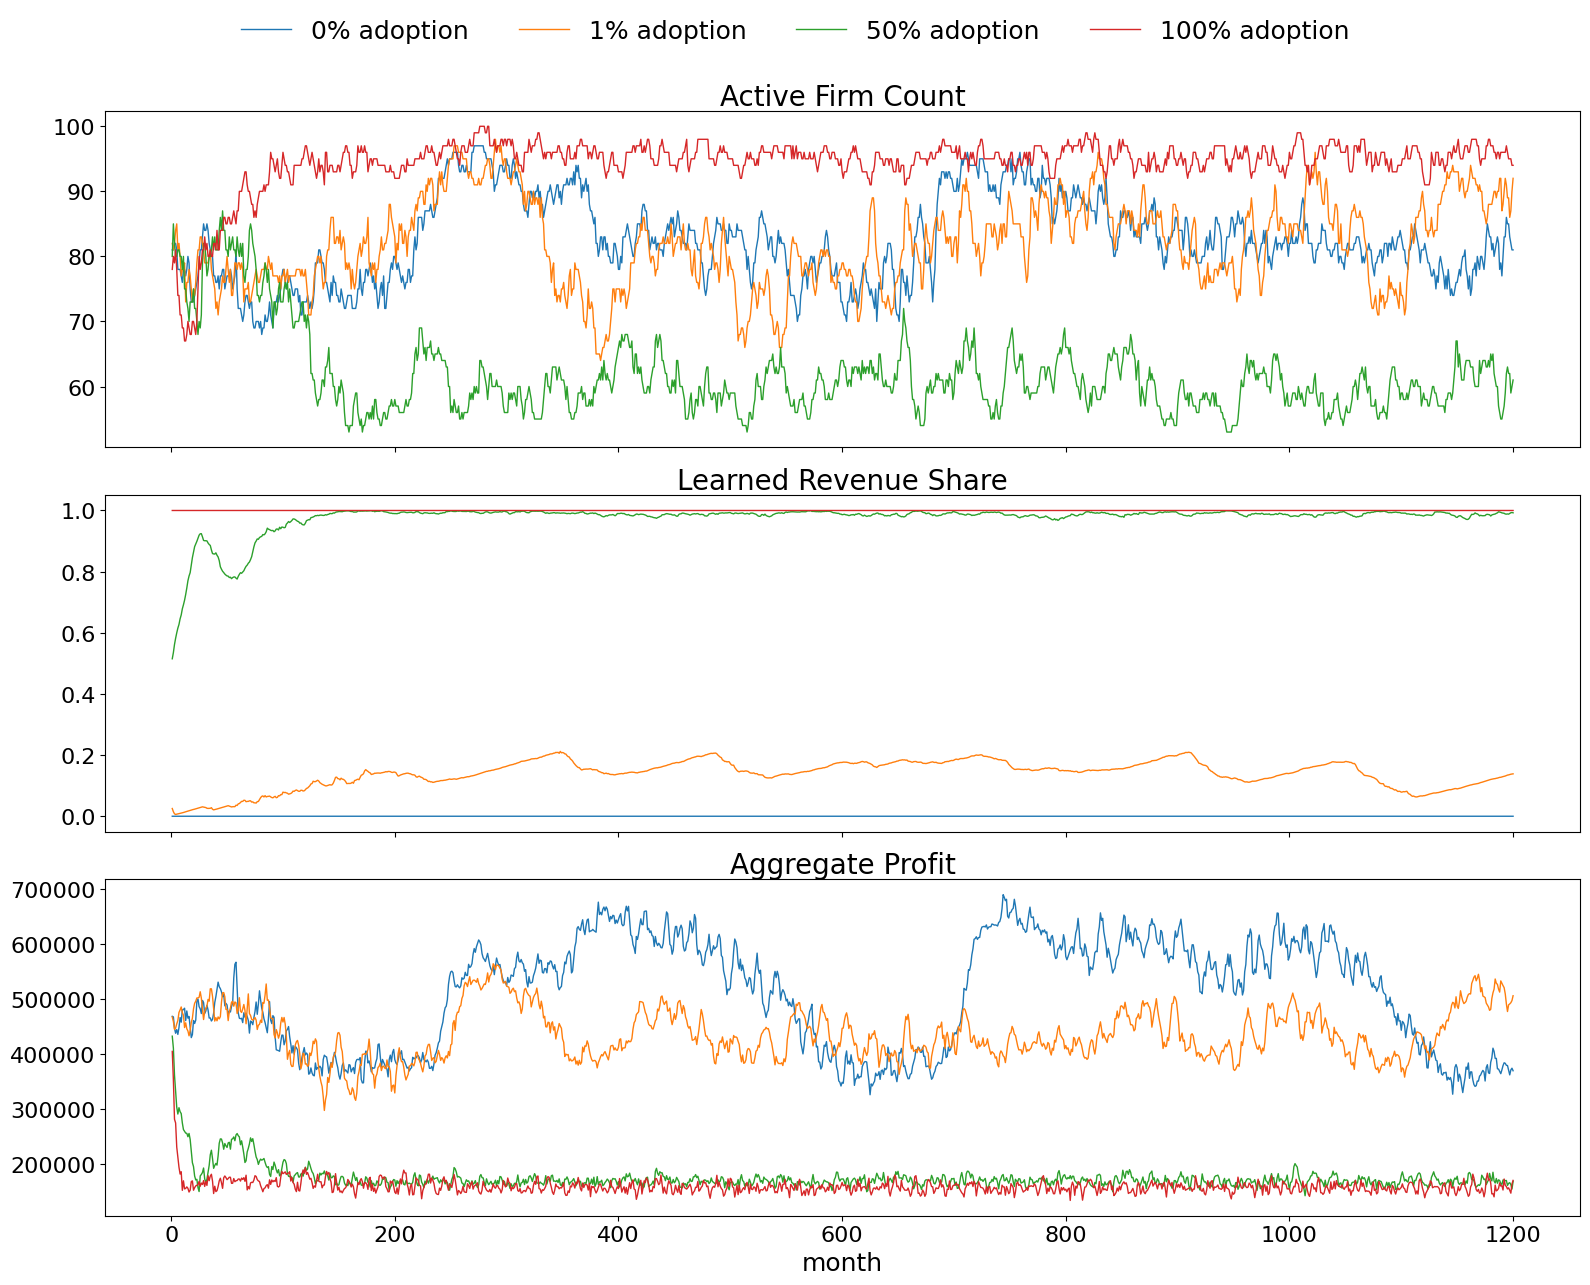

In [33]:
goods_sections = {
    "Statistic": [
        "active_firm_count",
        #"active_learned_firm_count",
        "learned_revenue_share",
        "aggregate_profit",
        #"max_revenue_share",
        #"revenue_hhi"
    ]
}

goods_metric_labels = {
    "active_firm_count": "Active firm count",
    "active_learned_firm_count": "Active learned firm count",
    "learned_revenue_share": "Learned firm revenue share",
    "aggregate_profit": "Aggregate profit",
}

goods_transform_map = {
    "mean_household_unsatisfied_demand": lambda x: 100 * x,
}

plot_adoption_trajectories_from_results(
    macro_results=macro_results,
    model_seed=20,
    run_seed=100,
    sections=goods_sections,
    #metric_labels=goods_metric_labels,
    transform_map=goods_transform_map,
    aggregation="monthly",   # or "yearly" if too noisy
    col_wrap=1,
    panel_height=4.0,
    aspect=4.0,
    show_suptitle=None,
    show_section_titles=False,
    download=True,
    filename="fig_9.pdf",
)